## Load Database

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, StandardScaler, PolynomialFeatures 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, f1_score, root_mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier, DummyRegressor

from scipy.stats import skew
from scipy import stats
from collections import Counter
from sklearn.datasets import make_classification, make_regression
tscv = TimeSeriesSplit(n_splits=5)

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from scipy import stats
from scipy.stats import ttest_rel

In [2]:
df = pd.read_excel(r"C:\Users\thilt\OneDrive\Desktop\Capstone Folder\Data\cleaned_FRA_data_no_targets.xlsx")
df.head(3)

,accidentyear,accidentmonth,accidenttype,stateabbreviation,district,temperature,visibilitycode,equipmenttype,weatherconditioncode,tracktype,...,conductorsonduty,brakemenonduty,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,hazmatcars,totaldamagecost,totalpersonskilled,totalpersonsinjured
0,2011,8,Hwy-rail crossing,IL,4,77,2.0,Yard/switching,1.0,Yard,...,1,0,5,0,4,0,0,17368,0,0
1,2013,12,Other impacts,IL,4,11,4.0,Yard/switching,1.0,Yard,...,1,1,1,0,1,0,0,35372,0,0
2,2018,5,Derailment,IA,6,60,1.0,Freight Train,2.0,Main,...,1,1,2,0,78,0,0,13442,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153995 entries, 0 to 153994
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   accidentyear           153995 non-null  int64  
 1   accidentmonth          153995 non-null  int64  
 2   accidenttype           153995 non-null  object 
 3   stateabbreviation      153995 non-null  object 
 4   district               153995 non-null  int64  
 5   temperature            153995 non-null  int64  
 6   visibilitycode         153995 non-null  float64
 7   equipmenttype          153995 non-null  object 
 8   weatherconditioncode   153995 non-null  float64
 9   tracktype              153995 non-null  object 
 10  passengerstransported  153995 non-null  object 
 11  headendlocomotives     153995 non-null  int64  
 12  traindirection         153995 non-null  object 
 13  trackclass             153995 non-null  object 
 14  engineersonduty        153995 non-nu

In [4]:
df.shape

(153995, 26)

In [5]:
df.describe()

,accidentyear,accidentmonth,district,temperature,visibilitycode,weatherconditioncode,headendlocomotives,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,hazmatcars,totaldamagecost,totalpersonskilled,totalpersonsinjured
count,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,153995.000000,1.539950e+05,153995.000000,153995.000000
mean,1994.459106,6.421884,4.450222,56.352972,2.829598,1.560219,2.245092,0.965181,0.106244,0.897633,1.039923,32.759914,0.198838,18.172934,0.073379,1.625390,8.458428e+04,0.019390,0.211987
std,15.427566,3.443358,1.966483,21.703032,1.034150,0.988545,1.454793,0.332386,0.311066,0.353159,0.896195,32.892996,1.318702,26.254453,0.746743,7.002258,3.462237e+05,0.243653,3.928027
min,1975.000000,1.000000,1.000000,-9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,1980.000000,3.000000,3.000000,40.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,9.025000e+03,0.000000,0.000000
50%,1991.000000,6.000000,4.000000,60.000000,2.000000,1.000000,2.000000,1.000000,0.000000,1.000000,1.000000,23.000000,0.000000,6.000000,0.000000,0.000000,1.852700e+04,0.000000,0.000000
75%,2007.000000,9.000000,6.000000,74.000000,4.000000,2.000000,3.000000,1.000000,0.000000,1.000000,2.000000,53.000000,0.000000,27.000000,0.000000,0.000000,4.913250e+04,0.000000,0.000000
max,2026.000000,12.000000,8.000000,99.000000,4.000000,6.000000,12.000000,3.000000,2.000000,3.000000,3.000000,140.000000,20.000000,140.000000,20.000000,169.000000,3.153875e+07,47.000000,558.000000


## Calculating Risk Score

### Train Test Split

In [6]:
df['totaldamagecost'].describe()

count    1.539950e+05
mean     8.458428e+04
std      3.462237e+05
min      0.000000e+00
25%      9.025000e+03
50%      1.852700e+04
75%      4.913250e+04
max      3.153875e+07
Name: totaldamagecost, dtype: float64

In [7]:
df['totalpersonskilled'].describe()

count    153995.000000
mean          0.019390
std           0.243653
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          47.000000
Name: totalpersonskilled, dtype: float64

In [8]:
df['totalpersonsinjured'].describe()

count    153995.000000
mean          0.211987
std           3.928027
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         558.000000
Name: totalpersonsinjured, dtype: float64

In [9]:
# Split data
df_year_sorted = df.sort_values('accidentyear')
train_cutoff = df_year_sorted['accidentyear'].quantile(0.6)
val_cutoff = df_year_sorted['accidentyear'].quantile(0.8)
print(f"Train Cut Off:", train_cutoff)
print(f"Val Cut Off:", val_cutoff)
print("\n")
#===========================================================================================
df_train_time = df_year_sorted[df_year_sorted['accidentyear'] <= train_cutoff]
df_val_time = df_year_sorted[(df_year_sorted['accidentyear'] > train_cutoff) & (df_year_sorted['accidentyear'] <= val_cutoff)]
df_test_time = df_year_sorted[df_year_sorted['accidentyear'] > val_cutoff]
#===========================================================================================
print(f"Train Time:{df_train_time['accidentyear'].min(), df_train_time['accidentyear'].max()}")
print(f"Validation Time:{df_val_time['accidentyear'].min(), df_val_time['accidentyear'].max()}")
print(f"Test Time:{df_test_time['accidentyear'].min(), df_test_time['accidentyear'].max()}")

Train Cut Off: 1997.0
Val Cut Off: 2011.0


Train Time:(1975, 1997)
Validation Time:(1998, 2011)
Test Time:(2012, 2026)


In [10]:
threshold_year = {1975:1750,1976:1750,1977:2300,1978:2300,1979:2900,1980:2900,1981:3700,1982:3700,
                  1983:4500,1984:4500,1985:4900,1986:4900,1987:5200,1988:5200,1989:5700,1990:5700,
                  1991:6300,1992:6300,1993:6300,1994:6300,1995:6300,1996:6300,1997:6500,1998:6600,
                  1999:6600,2000:6600,2001:6600,2002:6700,2003:6700,2004:6700,2005:6700,2006:7700,
                  2007:8200,2008:8500,2009:8900,2010:9200,2011:9400,2012:9500,2013:9900,2014:10500,
                  2015:10500,2016:10500,2017:10700,2018:10889,2019:10889,2020:10967,2021:11200,2022:11200,
                  2023:11200,2024:12000,2025:12400,2026:12600}
#===========================================================================================
df_train_time['threshold'] = df_train_time['accidentyear'].map(threshold_year)
df_val_time['threshold'] = df_val_time['accidentyear'].map(threshold_year)
df_test_time['threshold'] = df_test_time['accidentyear'].map(threshold_year)
#===========================================================================================
df_train_time['damage_ratio'] = df_train_time['totaldamagecost']/df_train_time['threshold']
df_val_time['damage_ratio'] = df_val_time['totaldamagecost']/df_val_time['threshold']
df_test_time['damage_ratio'] = df_test_time['totaldamagecost']/df_test_time['threshold']
#===========================================================================================
display(df_train_time[['accidentyear','totaldamagecost','threshold','damage_ratio']].head(3))
print('\n')
display(df_val_time[['accidentyear','totaldamagecost','threshold','damage_ratio']].head(3))
print('\n')
display(df_test_time[['accidentyear','totaldamagecost','threshold','damage_ratio']].head(3))

C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\3642991287.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['threshold'] = df_train_time['accidentyear'].map(threshold_year)
C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\3642991287.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['threshold'] = df_val_time['accidentyear'].map(threshold_year)
C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\3642991287.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy 

,accidentyear,totaldamagecost,threshold,damage_ratio
126645,1975,14325,1750,8.185714
124869,1975,1862,1750,1.064000
124868,1975,8357,1750,4.775429


,accidentyear,totaldamagecost,threshold,damage_ratio
31344,1998,558795,6600,84.665909
31343,1998,103639,6600,15.702879
31337,1998,28447,6600,4.310152


,accidentyear,totaldamagecost,threshold,damage_ratio
34500,2012,735102,9500,77.379158
5477,2012,14546,9500,1.531158
151538,2012,119600,9500,12.589474


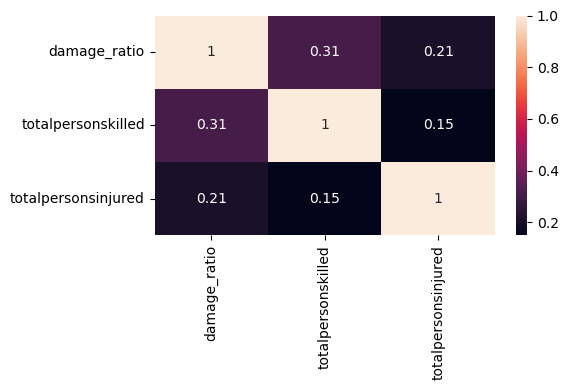

In [11]:
risk_ft = ['damage_ratio','totalpersonskilled', 'totalpersonsinjured']
plt.figure(figsize = (6,4))
heat_data = df_train_time[risk_ft].corr(numeric_only=True)
ax = sns.heatmap(heat_data, annot = True)
plt.tight_layout()

In [12]:
risk_ft = ['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured']
scaler = StandardScaler()
train_scaled = scaler.fit_transform(df_train_time[risk_ft])
val_scaled = scaler.transform(df_val_time[risk_ft])
test_scaled = scaler.transform(df_test_time[risk_ft])
#===========================================================================================
pca = PCA(n_components=1)
pca.fit(train_scaled)
#===========================================================================================
loading = np.abs(pca.components_[0])
weights = loading/loading.sum()
weight_series = pd.Series(weights, index=risk_ft)
print(weight_series)

damage_ratio           0.368638
totalpersonskilled     0.346178
totalpersonsinjured    0.285184
dtype: float64


In [13]:
df_train_time['risk_score'] = (train_scaled * weights).sum(axis=1)
df_val_time['risk_score'] = (val_scaled * weights).sum(axis=1)
df_test_time['risk_score'] = (test_scaled * weights).sum(axis=1)

C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\4010367082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['risk_score'] = (train_scaled * weights).sum(axis=1)
C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\4010367082.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['risk_score'] = (val_scaled * weights).sum(axis=1)
C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\4010367082.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [14]:
print("Train Top 5")
display(df_train_time[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured','risk_score']].sort_values('risk_score',ascending=False).head(5))
print("\n")
print("Validation Top 5")
display(df_val_time[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured','risk_score']].sort_values('risk_score',ascending=False).head(5))
print("\n")
print("Test Top 5")
display(df_test_time[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured','risk_score']].sort_values('risk_score',ascending=False).head(5))

Train Top 5


,damage_ratio,totalpersonskilled,totalpersonsinjured,risk_score
66227,1804.666667,47,103,82.590195
76968,2435.807692,16,177,51.687881
108853,14.285217,0,558,36.323527
108835,14.285217,0,558,36.323527
127816,23.448571,0,485,31.639963




Validation Top 5


,damage_ratio,totalpersonskilled,totalpersonsinjured,risk_score
51702,1537.782471,25,61,48.842803
40835,1466.204545,11,50,29.169732
147026,932.838511,6,101,21.702226
135142,1625.701493,4,0,17.979946
135682,1625.701493,4,0,17.979946




Test Top 5


,damage_ratio,totalpersonskilled,totalpersonsinjured,risk_score
138607,3003.690857,8,241,49.844962
12080,2414.112150,3,90,28.771703
25020,47.647789,0,385,25.316326
35906,1966.004554,3,83,24.768102
939,1594.725595,2,136,23.968307


In [15]:
print("Train Description")
display(df_train_time['risk_score'].describe())
print("\n")
print("Validation Description")
print(df_val_time['risk_score'].describe())
print("\n")
print("Test Description")
print(df_test_time['risk_score'].describe())

Train Description


count    9.322300e+04
mean     1.463418e-17
std      6.992346e-01
min     -1.444655e-01
25%     -1.300089e-01
50%     -1.166320e-01
75%     -6.605238e-02
max      8.259019e+01
Name: risk_score, dtype: float64



Validation Description
count    32123.000000
mean         0.009200
std          0.595510
min         -0.143284
25%         -0.129764
50%         -0.114333
75%         -0.058394
max         48.842803
Name: risk_score, dtype: float64


Test Description
count    28649.000000
mean         0.014560
std          0.705526
min         -0.144465
25%         -0.129712
50%         -0.113010
75%         -0.055297
max         49.844962
Name: risk_score, dtype: float64


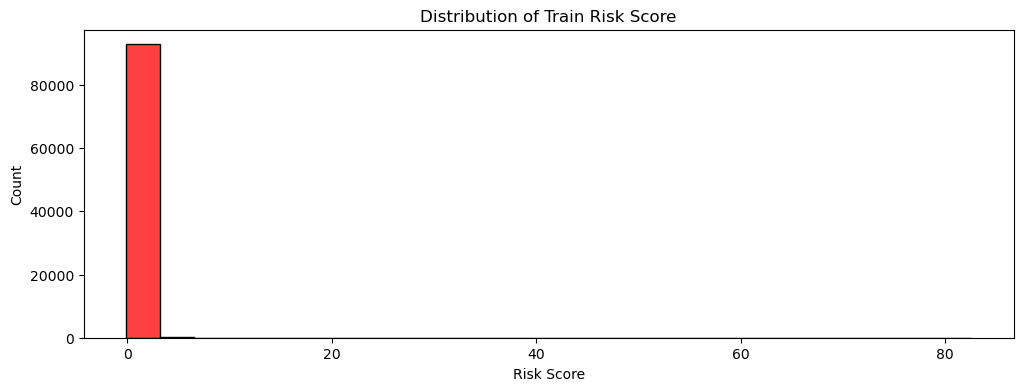

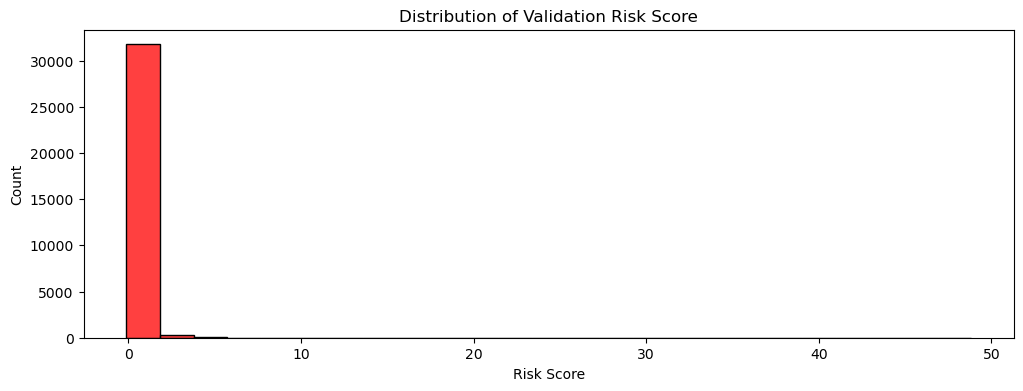

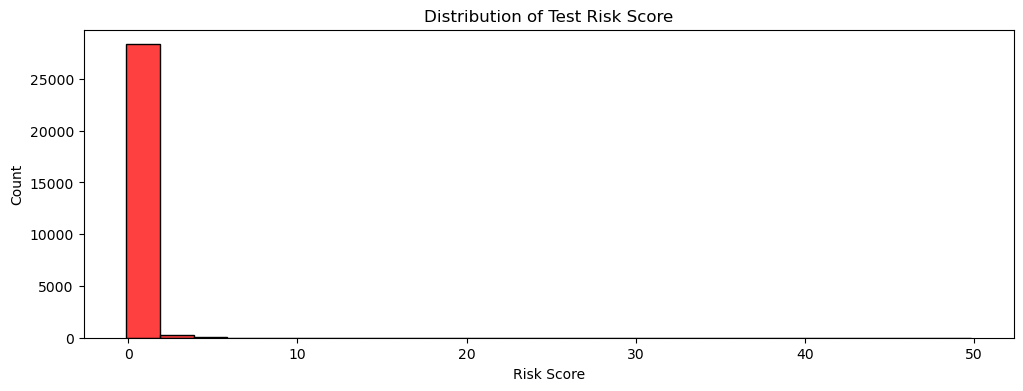

In [16]:
plt.figure(figsize=(12,4))
sns.histplot(data = df_train_time, x='risk_score', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Train Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_val_time, x='risk_score', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Validation Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_test_time, x='risk_score', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Test Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()

In [17]:
print("Train Description")
print(skew(df_train_time['risk_score']))
print("\n")
print("Validation Description")
print(skew(df_val_time['risk_score']))
print("\n")
print("Test Description")
print(skew(df_test_time['risk_score']))

Train Description
37.34842887331486


Validation Description
29.17953231908812


Test Description
28.00061808186526


### Power Transformation

In [18]:
transformer = PowerTransformer(method='yeo-johnson')
df_train_time['risk_score_yeo'] = transformer.fit_transform(df_train_time[['risk_score']])
df_val_time['risk_score_yeo'] = transformer.transform(df_val_time[['risk_score']])
df_test_time['risk_score_yeo'] = transformer.transform(df_test_time[['risk_score']])

C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\1296834791.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['risk_score_yeo'] = transformer.fit_transform(df_train_time[['risk_score']])
C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\1296834791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['risk_score_yeo'] = transformer.transform(df_val_time[['risk_score']])
C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\1296834791.py:4: SettingWithCopyWarning: 
A value is trying to

Text(0.5, 1.0, 'Probability Plot on Test After Yeo-Johnson')

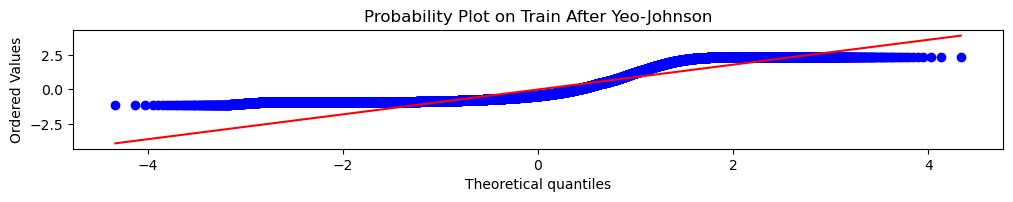

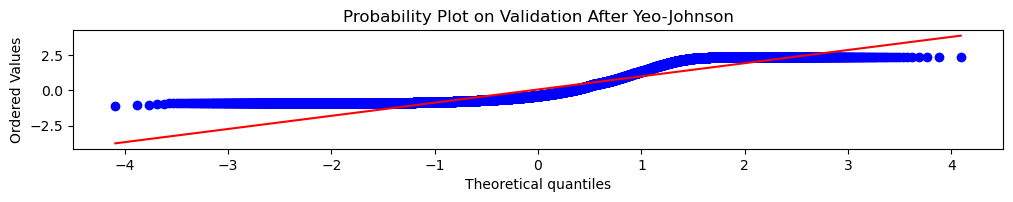

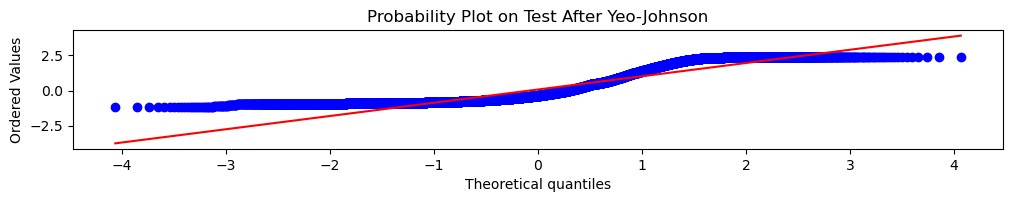

In [19]:
fig = plt.figure(figsize=(12,4))
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
prob1 = stats.probplot(df_train_time['risk_score_yeo'], dist='norm', plot=ax1)
ax1.set_title('Probability Plot on Train After Yeo-Johnson')
#===========================================================================================
fig = plt.figure(figsize=(12,4))
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
prob1 = stats.probplot(df_val_time['risk_score_yeo'], dist='norm', plot=ax1)
ax1.set_title('Probability Plot on Validation After Yeo-Johnson')
#===========================================================================================
fig = plt.figure(figsize=(12,4))
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
prob1 = stats.probplot(df_test_time['risk_score_yeo'], dist='norm', plot=ax1)
ax1.set_title('Probability Plot on Test After Yeo-Johnson')

In [20]:
print('Train Count')
print(df_train_time['risk_score_yeo'].value_counts().head(5))
print(df_train_time['risk_score_yeo'].value_counts().sort_index(ascending=False).head(5))
print('\n')
print('Validation Count')
print(df_val_time['risk_score_yeo'].value_counts().head(5))
print(df_val_time['risk_score_yeo'].value_counts().sort_index(ascending=False).head(5))
print('\n')
print('Test Count')
print(df_test_time['risk_score_yeo'].value_counts().head(5))
print(df_test_time['risk_score_yeo'].value_counts().sort_index(ascending=False).head(5))

Train Count
risk_score_yeo
-0.731762    275
-0.873532    241
-0.847763    223
-0.930204    221
-0.857958    219
Name: count, dtype: int64
risk_score_yeo
2.352817    1
2.352817    1
2.352817    2
2.352817    2
2.352817    2
Name: count, dtype: int64


Validation Count
risk_score_yeo
-0.834571    71
-0.684499    45
-0.896584    42
-0.865434    41
-0.541281    39
Name: count, dtype: int64
risk_score_yeo
2.352817    1
2.352817    1
2.352817    1
2.352817    2
2.352817    2
Name: count, dtype: int64


Test Count
risk_score_yeo
-0.847763    35
-0.866264    29
-0.685808    23
-0.750809    23
-0.798926    21
Name: count, dtype: int64
risk_score_yeo
2.352817    1
2.352817    1
2.352817    1
2.352817    1
2.352817    2
Name: count, dtype: int64


In [21]:
print("Train Description")
print(skew(df_train_time['risk_score_yeo']))
print("\n")
print("Validation Description")
print(skew(df_val_time['risk_score_yeo']))
print("\n")
print("Test Description")
print(skew(df_test_time['risk_score_yeo']))

Train Description
1.1438844746715804


Validation Description
1.0474247000220682


Test Description
0.9860043476267282


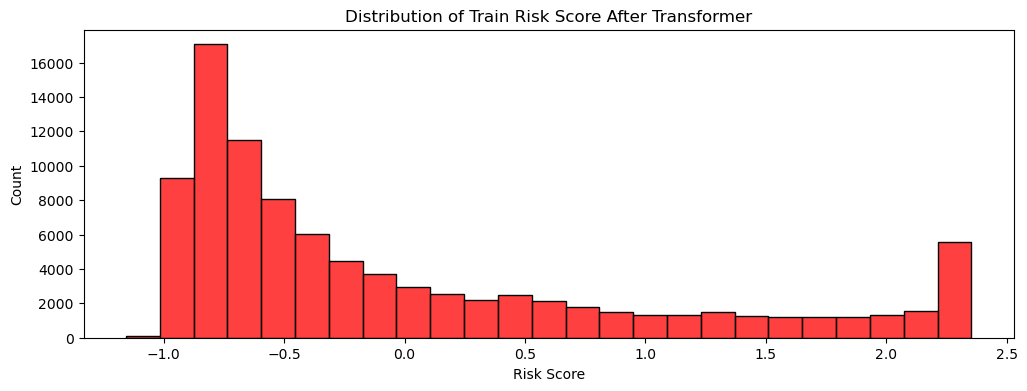

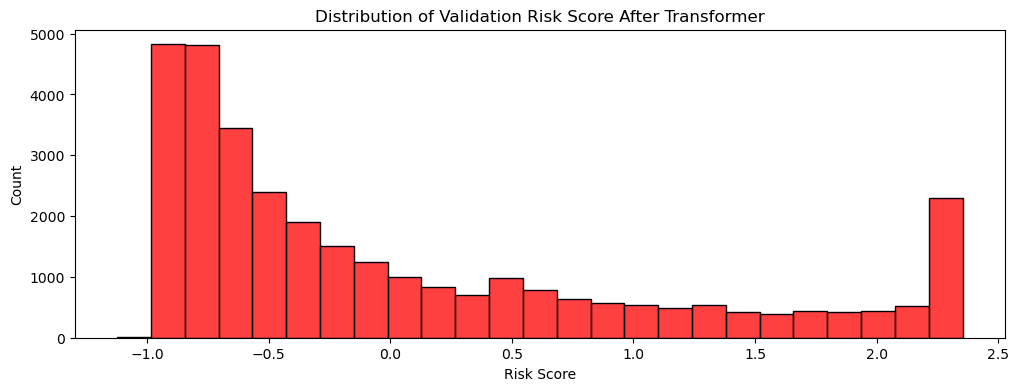

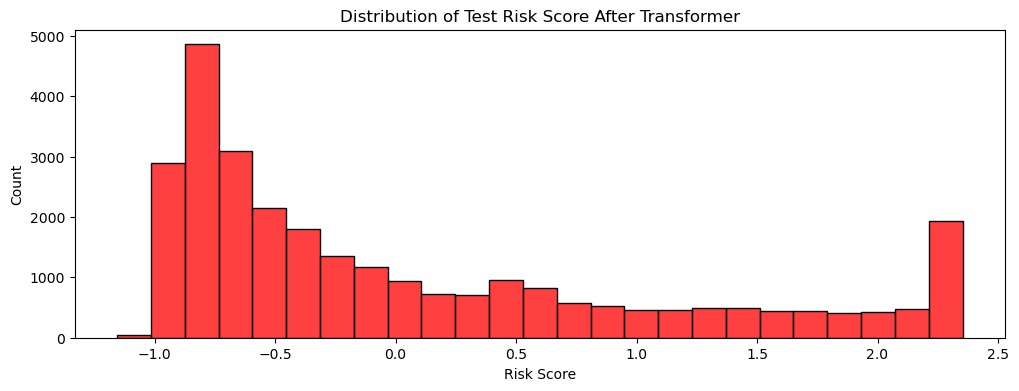

In [22]:
plt.figure(figsize=(12,4))
sns.histplot(data = df_train_time, x='risk_score_yeo', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Train Risk Score After Transformer')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_val_time, x='risk_score_yeo', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Validation Risk Score After Transformer')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()
#===========================================================================================
plt.figure(figsize=(12,4))
sns.histplot(data = df_test_time, x='risk_score_yeo', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Test Risk Score After Transformer')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()

### Risk Category

In [23]:
df_train_time['risk_category'], bin_edges = pd.qcut(df_train_time['risk_score_yeo'], q=2, labels = ['Low Severity', 'High Severity'], retbins=True) # retbins: Returns bins and labels
#===========================================================================================
df_val_time['risk_category'] = pd.cut(df_val_time['risk_score_yeo'], bins=bin_edges, labels = ['Low Severity', 'High Severity'], include_lowest=True) # include_lowest: Keeps the lowest value in
df_test_time['risk_category'] = pd.cut(df_test_time['risk_score_yeo'], bins=bin_edges, labels = ['Low Severity', 'High Severity'], include_lowest=True)

C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\3582018591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_time['risk_category'], bin_edges = pd.qcut(df_train_time['risk_score_yeo'], q=2, labels = ['Low Severity', 'High Severity'], retbins=True) # retbins: Returns bins and labels
C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\3582018591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_time['risk_category'] = pd.cut(df_val_time['risk_score_yeo'], bins=bin_edges, labels = ['Low Sev

In [24]:
print(df_train_time['risk_category'].value_counts())
print("\n")
print("Validation Category Count")
print(df_val_time['risk_category'].value_counts())
print("\n")
print("Test Category Count")
print(df_test_time['risk_category'].value_counts())

risk_category
Low Severity     46612
High Severity    46611
Name: count, dtype: int64


Validation Category Count
risk_category
High Severity    16841
Low Severity     15282
Name: count, dtype: int64


Test Category Count
risk_category
High Severity    15449
Low Severity     13200
Name: count, dtype: int64


In [25]:
print("Bin Thresholds")
bin_edges = [round(bin,3) for bin in bin_edges]
print(bin_edges)

Bin Thresholds
[np.float64(-1.156), np.float64(-0.443), np.float64(2.353)]


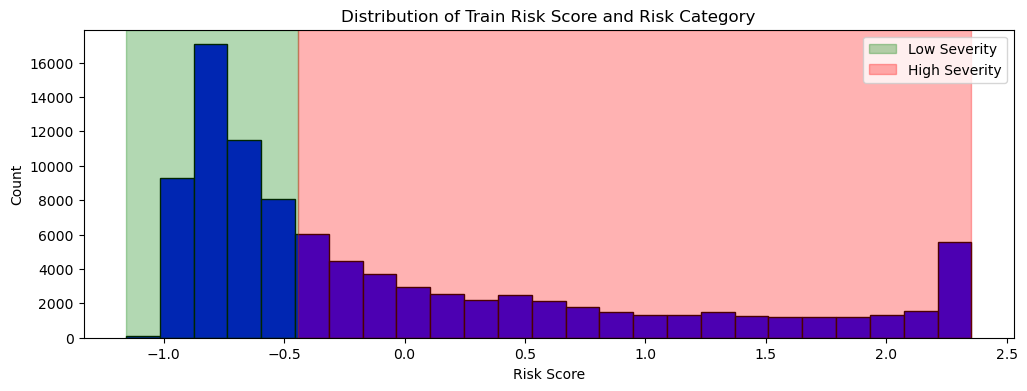

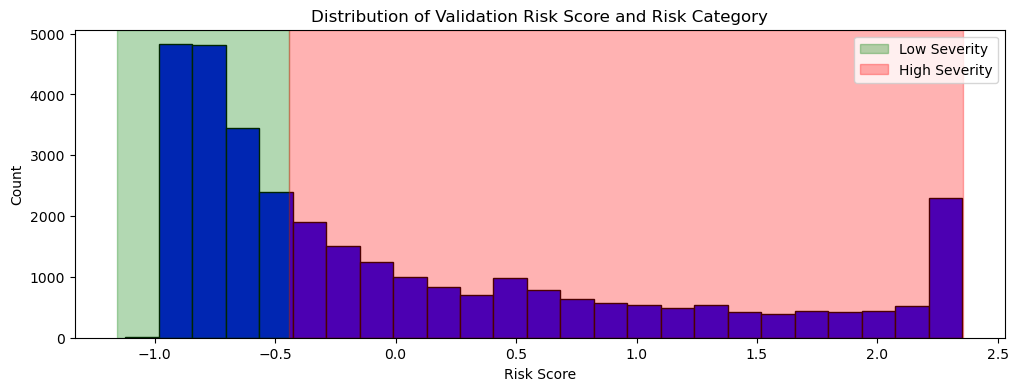

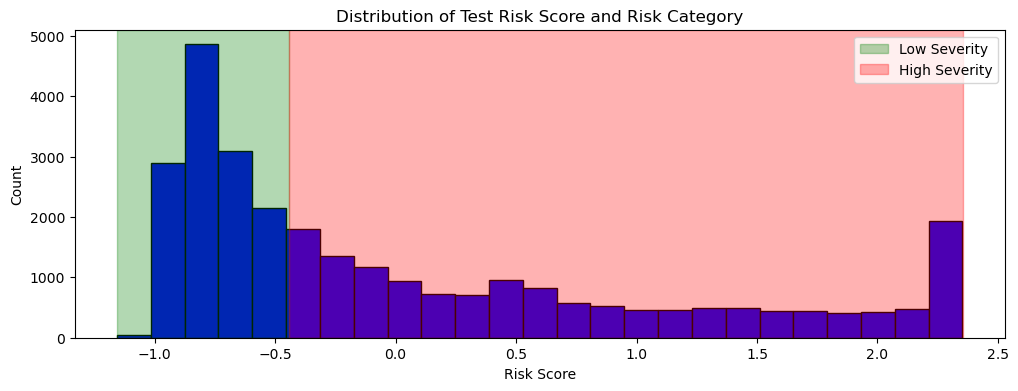

In [26]:
def plot_bins(data, title, bins):
    plt.figure(plt.figure(figsize=(12,4)))
    plt.hist(data, bins=25, color='blue', edgecolor='black')
    plt.axvspan(bins[0], bins[1], color='green', alpha=0.3, label='Low Severity')
    plt.axvspan(bins[1], bins[2], color='red', alpha=0.3, label='High Severity')
    plt.title(title)
    plt.xlabel('Risk Score')
    plt.ylabel('Count')
    plt.legend()
    plt.show
#===========================================================================================
plot_bins(df_train_time['risk_score_yeo'],"Distribution of Train Risk Score and Risk Category",bin_edges)
plot_bins(df_val_time['risk_score_yeo'],"Distribution of Validation Risk Score and Risk Category",bin_edges)
plot_bins(df_test_time['risk_score_yeo'],"Distribution of Test Risk Score and Risk Category",bin_edges)

In [27]:
df_train_time.groupby('risk_category')[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured']].describe()

C:\Users\thilt\AppData\Local\Temp\ipykernel_25112\3965795046.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train_time.groupby('risk_category')[['damage_ratio', 'totalpersonskilled', 'totalpersonsinjured']].describe()


damage_ratio                                                 \
                     count       mean        std  min       25%       50%   
risk_category                                                               
Low Severity       46612.0   1.961947   0.700748  0.0  1.368966  1.826087   
High Severity      46611.0  24.581297  63.877540  0.0  4.793651  8.047619   

                                      totalpersonskilled            ...       \
                     75%          max              count      mean  ...  75%   
risk_category                                                       ...        
Low Severity    2.478261     3.515789            46612.0  0.000000  ...  0.0   
High Severity  19.076451  2435.807692            46611.0  0.038296  ...  0.0   

                    totalpersonsinjured                                     \
                max               count      mean       std  min  25%  50%   
risk_category                                                                
Low Severity    0.0             46612.0  0.000000  0.000000  0.0  0.0  0.0   
High Severity  47.0             46611.0  0.437365  6.182659  0.0  0.0  0.0   

                           
               75%    max  
risk_category              
Low Severity   0.0    0.0  
High Severity  0.0  558.0  

[2 rows x 24 columns]

### EDA

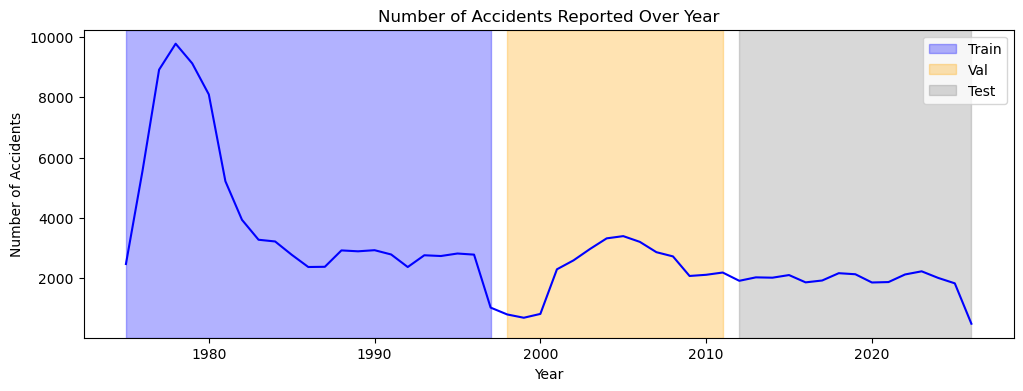

In [28]:
plt.figure(figsize=(12, 4))
accident_year = df.groupby('accidentyear').size()
sns.lineplot(x=accident_year.index, y=accident_year.values, color="blue")
plt.axvspan(1975, 1997, color='blue', alpha=0.3, label='Train')
plt.axvspan(1998, 2011, color='orange', alpha=0.3, label='Val')
plt.axvspan(2012, 2026, color='grey', alpha=0.3, label='Test')
plt.title('Number of Accidents Reported Over Year')
plt.ylabel('Number of Accidents')
plt.xlabel('Year')
plt.legend()
plt.show()

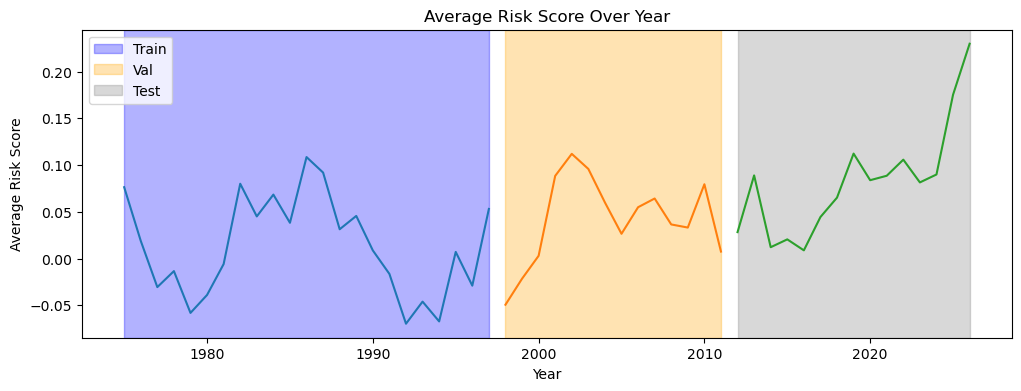

In [29]:
train_trend = df_train_time.groupby('accidentyear')['risk_score_yeo'].mean()
val_trend = df_val_time.groupby('accidentyear')['risk_score_yeo'].mean()
test_trend = df_test_time.groupby('accidentyear')['risk_score_yeo'].mean()
#===========================================================================================
plt.figure(figsize=(12, 4))
sns.lineplot(x=train_trend.index, y=train_trend.values)
sns.lineplot(x=val_trend.index, y=val_trend.values)
sns.lineplot(x=test_trend.index, y=test_trend.values)
plt.axvspan(1975, 1997, color='blue', alpha=0.3, label='Train')
plt.axvspan(1998, 2011, color='orange', alpha=0.3, label='Val')
plt.axvspan(2012, 2026, color='grey', alpha=0.3, label='Test')
plt.title('Average Risk Score Over Year')
plt.ylabel('Average Risk Score')
plt.xlabel('Year')
plt.legend()
plt.show()

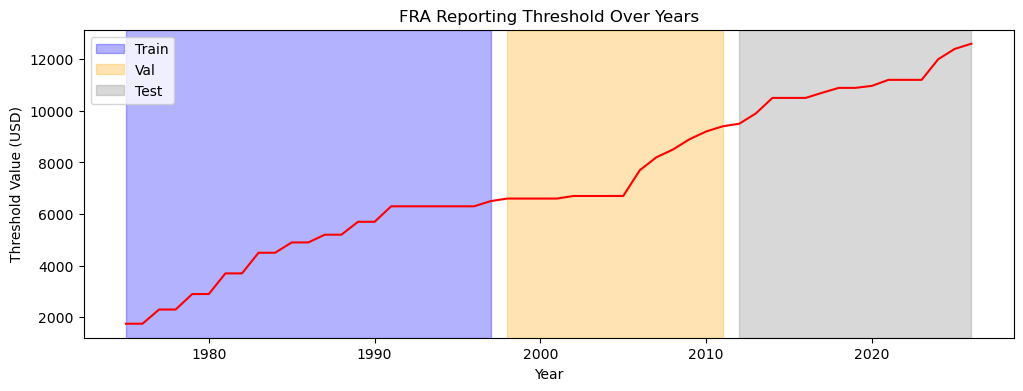

In [30]:
year = list(range(1975,2027))
threshold = [1750,1750,2300,2300,2900,2900,3700,3700,4500,4500,4900,4900,5200,5200,5700,5700,6300,6300,6300,6300,6300,6300,6500,6600,6600,6600,6600,6700,6700,6700,6700,7700,8200,8500,8900,9200,9400,9500,9900,10500,10500,10500,10700,10889,10889,10967,11200,11200,11200,12000,12400,12600]
#===========================================================================================
plt.figure(figsize=(12, 4))
plt.plot(year,threshold,color='red')
plt.axvspan(1975, 1997, color='blue', alpha=0.3, label='Train')
plt.axvspan(1998, 2011, color='orange', alpha=0.3, label='Val')
plt.axvspan(2012, 2026, color='grey', alpha=0.3, label='Test')
plt.title("FRA Reporting Threshold Over Years")
plt.xlabel("Year")
plt.ylabel("Threshold Value (USD)")
plt.legend()
plt.show()

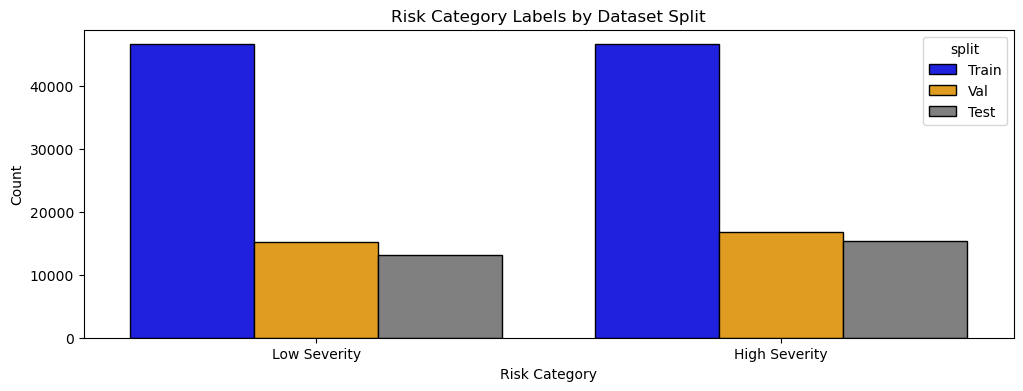

In [31]:
x_order = ['Low Severity','High Severity']
combined = pd.concat([df_train_time[['risk_category']].assign(split="Train"),
                      df_val_time[['risk_category']].assign(split="Val"),
                       df_test_time[['risk_category']].assign(split="Test")], ignore_index=True)
#===========================================================================================
plt.figure(figsize=(12,4))
sns.countplot(combined, x='risk_category', hue = 'split', edgecolor = 'black', order = x_order, palette = ['blue','orange','grey'])
plt.title('Risk Category Labels by Dataset Split')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.show()

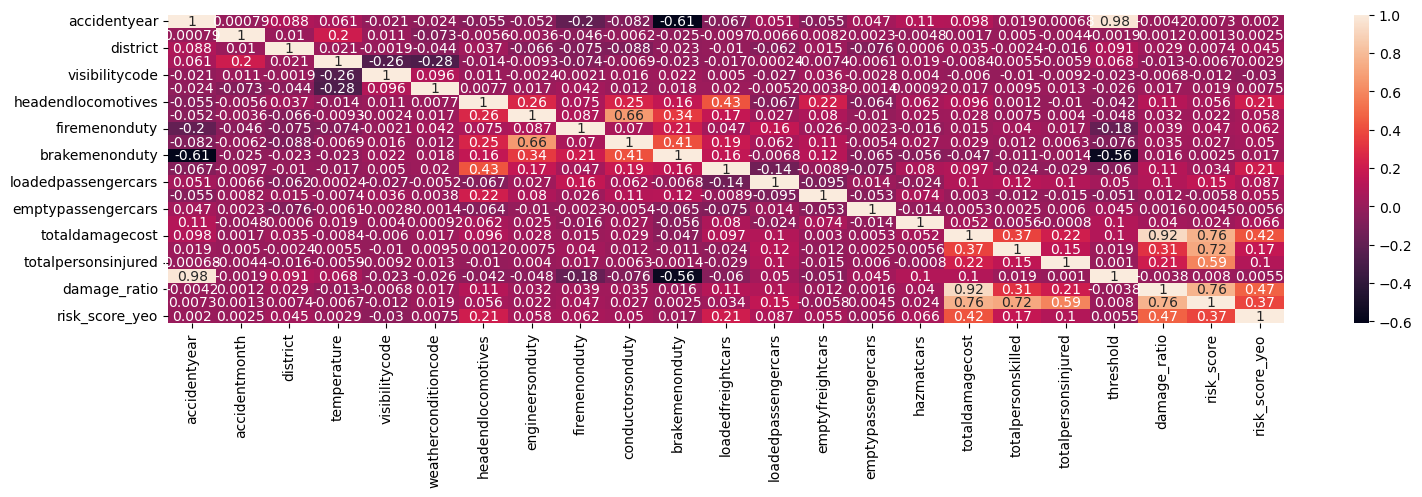

In [32]:
plt.figure(figsize=(18,4))
plt.tight_layout
sns.heatmap(df_train_time.corr(numeric_only=True), annot=True)
plt.show()

In [33]:
cat = df_train_time.select_dtypes(include='object').columns
print(cat)
print('\n')
print("Categorical Number of Unique Values")
for c in cat:
    print(c,':',df_train_time[c].nunique())
#===========================================================================================
print('\n')
cat_list = ['accidenttype','district','visibilitycode','equipmenttype','weatherconditioncode','tracktype','trackclass']
for c in cat_list:
    print(c)
    print(df_train_time.groupby(c)['risk_score_yeo'].mean().sort_values())
    print("\n")

Index(['accidenttype', 'stateabbreviation', 'equipmenttype', 'tracktype',
       'passengerstransported', 'traindirection', 'trackclass'],
      dtype='object')


Categorical Number of Unique Values
accidenttype : 12
stateabbreviation : 50
equipmenttype : 9
tracktype : 4
passengerstransported : 2
traindirection : 4
trackclass : 8


accidenttype
accidenttype
Other impacts            -0.360014
Side collision           -0.238361
Raking collision         -0.176580
Explosion-detonation     -0.092887
Obstruction              -0.016169
Derailment               -0.008055
Fire/violent rupture     -0.007191
Broken train collision    0.204842
Rear end collision        0.535110
Hwy-rail crossing         0.792314
Head on collision         0.822953
RR grade crossing         0.891320
Name: risk_score_yeo, dtype: float64


district
district
4   -0.119792
2   -0.059856
1   -0.032546
5    0.019413
3    0.026873
7    0.031582
6    0.086570
8    0.094215
Name: risk_score_yeo, dtype: float64


visibilityco

In [34]:
drop_list = ['totaldamagecost', 'totalpersonskilled', 'totalpersonsinjured','threshold','damage_ratio','risk_score']
df_train_time = df_train_time.drop(columns = drop_list, axis=1)
df_val_time = df_val_time.drop(columns = drop_list, axis=1)
df_test_time = df_test_time.drop(columns = drop_list, axis=1)
df_train_time.columns.to_list()

['accidentyear',
 'accidentmonth',
 'accidenttype',
 'stateabbreviation',
 'district',
 'temperature',
 'visibilitycode',
 'equipmenttype',
 'weatherconditioncode',
 'tracktype',
 'passengerstransported',
 'headendlocomotives',
 'traindirection',
 'trackclass',
 'engineersonduty',
 'firemenonduty',
 'conductorsonduty',
 'brakemenonduty',
 'loadedfreightcars',
 'loadedpassengercars',
 'emptyfreightcars',
 'emptypassengercars',
 'hazmatcars',
 'risk_score_yeo',
 'risk_category']

### Preparing Datasets

In [35]:
# KNN Target Variable
y_train_knn = df_train_time['risk_category']
y_val_knn = df_val_time['risk_category']
y_test_knn = df_test_time['risk_category']
#===========================================================================================
# Linear Regression Variable
y_train_lin = df_train_time['risk_score_yeo']
y_val_lin = df_val_time['risk_score_yeo']
y_test_lin = df_test_time['risk_score_yeo']
#===========================================================================================
# Splitting for modeling
X_train = df_train_time.drop(columns=['risk_category','risk_score_yeo'])
X_val = df_val_time.drop(columns=['risk_category','risk_score_yeo'])
X_test = df_test_time.drop(columns=['risk_category','risk_score_yeo'])

In [36]:
print(f"Train Time Order: {df_train_time['accidentyear'].is_monotonic_increasing}")
print(f"Validation Time Order: {df_val_time['accidentyear'].is_monotonic_increasing}")
print(f"Test Time Order: {df_test_time['accidentyear'].is_monotonic_increasing}")

Train Time Order: True
Validation Time Order: True
Test Time Order: True


In [37]:
categorical_cols = X_train.select_dtypes(include=['object']).columns # Subset categorical features

X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_val[categorical_cols] = X_val[categorical_cols].astype(str)
X_test[categorical_cols] = X_test[categorical_cols].astype(str)

encode = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encode = encode.fit_transform(X_train[categorical_cols])
val_encode = encode.transform(X_val[categorical_cols])
test_encode = encode.transform(X_test[categorical_cols])
#===========================================================================================
# Created an array. Claude AI was used to help trouble shoot how to return a dataframe. 
train_encode_df = pd.DataFrame(train_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_train.index)
val_encode_df = pd.DataFrame(val_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_val.index)
test_encode_df = pd.DataFrame(test_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_test.index)
#===========================================================================================
X_train=X_train.drop(columns=categorical_cols).join(train_encode_df)
X_val=X_val.drop(columns=categorical_cols).join(val_encode_df)
X_test=X_test.drop(columns=categorical_cols).join(test_encode_df)

In [38]:
continuous_cols = ['accidentyear','hazmatcars','temperature','engineersonduty','firemenonduty','conductorsonduty','brakemenonduty','headendlocomotives','loadedfreightcars','loadedpassengercars','emptyfreightcars','emptypassengercars']
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols]) 

In [39]:
X_train['month_sin'] = np.sin(X_train['accidentmonth'] * (2 * np.pi / 12))
X_train['month_cos'] = np.cos(X_train['accidentmonth'] * (2 * np.pi / 12))
X_val['month_sin'] = np.sin(X_val['accidentmonth'] * (2 * np.pi / 12))
X_val['month_cos'] = np.cos(X_val['accidentmonth'] * (2 * np.pi / 12))
X_test['month_sin'] = np.sin(X_test['accidentmonth'] * (2 * np.pi / 12))
X_test['month_cos'] = np.cos(X_test['accidentmonth'] * (2 * np.pi / 12))
#===========================================================================================
X_train=X_train.drop(columns=['accidentmonth'])
X_val=X_val.drop(columns=['accidentmonth'])
X_test=X_test.drop(columns=['accidentmonth'])

In [40]:
X_train.columns

Index(['accidentyear', 'district', 'temperature', 'visibilitycode',
       'weatherconditioncode', 'headendlocomotives', 'engineersonduty',
       'firemenonduty', 'conductorsonduty', 'brakemenonduty',
       ...
       'trackclass_0', 'trackclass_1', 'trackclass_2', 'trackclass_3',
       'trackclass_4', 'trackclass_5', 'trackclass_6', 'trackclass_X',
       'month_sin', 'month_cos'],
      dtype='object', length=106)

### Feature Correlation and Importance

In [41]:
# Correlation to Risk Score
corr = X_train.join(y_train_lin).corr(numeric_only=True)['risk_score_yeo'].sort_values(ascending=False)
print(corr)

risk_score_yeo                  1.000000
tracktype_Main                  0.398859
trackclass_4                    0.236499
equipmenttype_Freight Train     0.235753
trackclass_3                    0.221521
                                  ...   
tracktype_Industry             -0.093446
accidenttype_Other impacts     -0.095512
equipmenttype_Yard/switching   -0.252996
tracktype_Yard                 -0.356208
trackclass_1                   -0.371441
Name: risk_score_yeo, Length: 107, dtype: float64


In [42]:
# Implement Decision Tree Regression
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train_lin)
importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                           Score
tracktype_Main                          0.159095
loadedfreightcars                       0.096482
temperature                             0.088071
accidentyear                            0.069544
emptyfreightcars                        0.069275
...                                          ...
stateabbreviation_DC                    0.000194
accidenttype_RR grade crossing          0.000042
trackclass_0                            0.000003
equipmenttype_Commuter Train - Pulling  0.000000
equipmenttype_Maint./inspect Car        0.000000

[106 rows x 1 columns]


In [43]:
# Implement Decision Tree Classification
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train_knn)
importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                           Score
temperature                             0.107835
loadedfreightcars                       0.102483
tracktype_Main                          0.094119
emptyfreightcars                        0.083493
accidentyear                            0.077708
...                                          ...
accidenttype_Explosion-detonation       0.000106
accidenttype_RR grade crossing          0.000086
trackclass_0                            0.000062
equipmenttype_Commuter Train - Pulling  0.000000
equipmenttype_Maint./inspect Car        0.000000

[106 rows x 1 columns]


### Baseline Model - Linear Regression

In [44]:
lin_by = LinearRegression()
lin_by.fit(X_train, y_train_lin)
#===========================================================================================
pred_train_lin_by=lin_by.predict(X_train)
pred_val_lin_by=lin_by.predict(X_val)
rmse_train_by = np.sqrt(mean_squared_error(y_train_lin, pred_train_lin_by))
rmse_val_by = np.sqrt(mean_squared_error(y_val_lin, pred_val_lin_by))
gap_by = rmse_val_by - rmse_train_by
r2_val = r2_score(y_val_lin, pred_val_lin_by)
#===========================================================================================
print(f" Train RMSE: {rmse_train_by:.3f}")
print(f" Val RMSE: {rmse_val_by:.3f}")
print(f" Gap: {gap_by:.3f}")
print(f" R2-Score: {r2_val:.3f}")

 Train RMSE: 0.864
 Val RMSE: 0.889
 Gap: 0.025
 R2-Score: 0.252


### Tuned Linear Regression with Year Weights

In [45]:
train_year = df_train_time['accidentyear']
year_weights = train_year - train_year.min() + 1
lin_weight = LinearRegression()
lin_weight.fit(X_train, y_train_lin, sample_weight = year_weights)
#===========================================================================================
pred_train_weight=lin_weight.predict(X_train)
pred_val_weight=lin_weight.predict(X_val)
rmse_train_weight = np.sqrt(mean_squared_error(y_train_lin, pred_train_weight))
rmse_val_weight = np.sqrt(mean_squared_error(y_val_lin, pred_val_weight))
gap_by_weight = rmse_val_weight - rmse_train_weight
r2_val_weight = r2_score(y_val_lin, pred_val_weight)
#===========================================================================================
print(f"Train RMSE: {rmse_train_weight:.3f}")
print(f"Val RMSE: {rmse_val_weight:.3f}")
print(f"Gap: {gap_by_weight:.3f}")
print(f"R2-Score: {r2_val_weight:.3f}")

Train RMSE: 0.865
Val RMSE: 0.886
Gap: 0.021
R2-Score: 0.257


### Tuned Linear Regression with Year Weights and Best K Selected

In [46]:
selector = SelectKBest(score_func = f_regression)
pipeline = Pipeline([('selector',selector),('regression',lin_weight)])
param_grid = {'selector__k': range(1, X_train.shape[1] + 1)}
#===========================================================================================
grid_lin = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_lin.fit(X_train, y_train_lin)
best_k = grid_lin.best_params_['selector__k']
print(f"Best K:", best_k)
#===========================================================================================
selector = SelectKBest(score_func = f_regression, k=116)
X_train_selected = selector.fit_transform(X_train, y_train_lin)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)
selected_feat = X_train.columns[selector.get_support()]
# #print(f"Features Selected:{list(selected_feat)}")
#===========================================================================================
lin_weight.fit(X_train_selected, y_train_lin, sample_weight = year_weights)

pred_train_bk=lin_weight.predict(X_train_selected)
pred_val_bk=lin_weight.predict(X_val_selected)
rmse_train_bk = np.sqrt(mean_squared_error(y_train_lin, pred_train_bk))
rmse_val_bk = np.sqrt(mean_squared_error(y_val_lin, pred_val_bk))
gap_by_bk = rmse_val_bk - rmse_train_bk
r2_val_bk = r2_score(y_val_lin, pred_val_bk)
#===========================================================================================
print(f"Train RMSE: {rmse_train_bk:.3f}")
print(f"Val RMSE: {rmse_val_bk:.3f}")
print(f"Gap: {gap_by_bk:.3f}")
print(f"R2-Score: {r2_val_bk:.3f}")

Best K: 101


C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(


Train RMSE: 0.865
Val RMSE: 0.886
Gap: 0.021
R2-Score: 0.257


### Linear Regression Result Evaluation

In [47]:
RMSE = [['Linear Regression', rmse_train_by, rmse_val_by, gap_by, r2_val],
       ['Linear Regression with Year Weights',rmse_train_weight, rmse_val_weight, gap_by_weight, r2_val_weight],
       ['Linear Regression with Year Weights and Best K Selected', rmse_train_bk, rmse_val_bk, gap_by_bk, r2_val_bk]]
#===========================================================================================
Base_Model=pd.DataFrame(RMSE, columns = ['Model Name','Train RMSE','Test RMSE','Gap', 'R2'])
Base_Model

,Model Name,Train RMSE,Test RMSE,Gap,R2
0,Linear Regression,0.863915,0.889296,0.025381,0.251642
1,Linear Regression with Year Weights,0.864817,0.886224,0.021407,0.256804
2,Linear Regression with Year Weights and Best K...,0.864817,0.886224,0.021407,0.256804


#### Linear Regression Year Weights and Best K Selected Evaluated

In [48]:
pipeline_best = Pipeline([('selector',SelectKBest(score_func = f_regression, k=116)),('regression',lin_weight)])

In [49]:
score_lin = cross_val_score(pipeline_best, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
rmse_score = -score_lin
print("Linear Regression Weights and K=116")
print(f"Mean RMSE: {rmse_score.mean():.3f}")
print(f"Std RMSE: {rmse_score.std():.3f}")
print(f"Per-fold: {rmse_score}")
print("\n")
#===========================================================================================
score_lin_r2 = cross_val_score(pipeline_best, X_train, y_train_lin, cv=tscv, scoring='r2')
r2_cs = score_lin_r2
print("Linear Regression Weights and K=116")
print(f"Mean R2-Score: {r2_cs.mean():.3f}")
print(f"Std R2-Score: {r2_cs.std():.3f}")
print(f"Per-fold: {r2_cs}")

C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warni

Linear Regression Weights and K=116
Mean RMSE: 0.863
Std RMSE: 0.017
Per-fold: [0.86736484 0.85455361 0.88080568 0.87986342 0.8342983 ]




C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warni

Linear Regression Weights and K=116
Mean R2-Score: 0.249
Std R2-Score: 0.017
Per-fold: [0.22684868 0.2349266  0.24723003 0.2609424  0.27335435]


C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warnings.warn(
C:\Users\thilt\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=116 is greater than n_features=106. All the features will be returned.
  warni

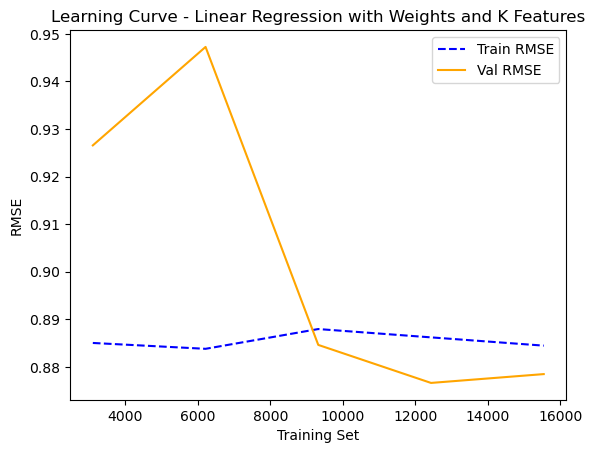

In [50]:
from sklearn.model_selection import learning_curve
sizes, train_scores, val_scores = learning_curve(
    pipeline_best,
    X_train, 
    y_train_lin,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0],
)
#===========================================================================================
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_rmse, '--', color='blue', label='Train RMSE')
plt.plot(sizes, val_rmse, color='orange', label='Val RMSE')
plt.xlabel('Training Set')
plt.ylabel('RMSE')
plt.legend()
plt.title('Learning Curve - Linear Regression with Weights and K Features')
plt.show()

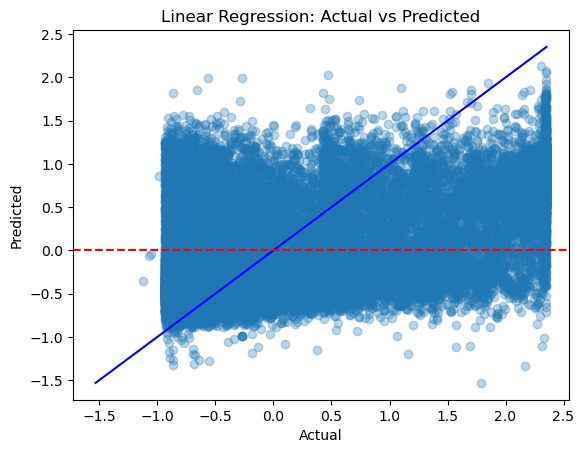

In [51]:
plt.scatter(y_val_lin, pred_val_bk, alpha=0.3)
p1 = max(max(pred_val_bk), max(y_val_lin))
p2 = min(min(pred_val_bk), min(y_val_lin))
plt.plot([p1,p2],[p1,p2],'b-')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

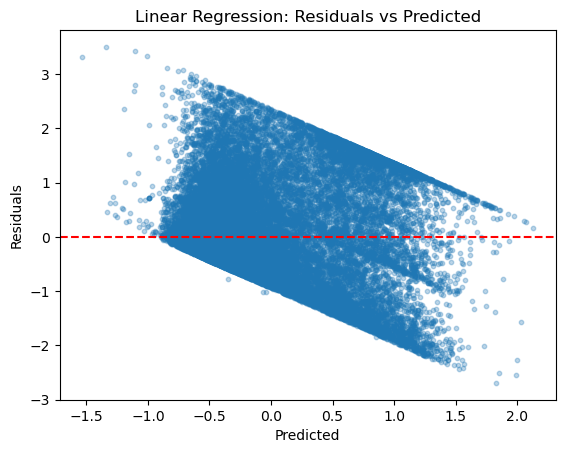

In [52]:
resid = y_val_lin - pred_val_bk
plt.scatter(pred_val_bk, resid, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residuals vs Predicted')
plt.show()

### Non-Linear Regression Models

In [53]:
# param_grid = {
#     'n_estimators': [700,800,900],
#     'max_depth': [6,7],
#     'learning_rate': [0.01,0.05],
#     'subsample': [0.7,0.9],
#     'colsample_bytree': [0.7,0.9]
# }

# xgbr = XGBRegressor(objective='reg:squarederror',random_state=42)
# grid_xgbr = GridSearchCV(xgbr, param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
# grid_xgbr.fit(X_train, y_train_lin)
# print(f"Best params: {grid_xgbr.best_params_}")
# print(f"Best CV RMSE: {-grid_xgbr.best_score_}")
#=======================================================================================================
# Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.7}
# Best CV RMSE: 0.8406326184132649

#### Non-Linear Regression Evaluated

In [54]:
xgbr = XGBRegressor(objective='reg:squarederror',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7)
xgbr.fit(X_train, y_train_lin)
#===========================================================================================
pred_train_xgbr=xgbr.predict(X_train)
pred_val_xgbr=xgbr.predict(X_val)
rmse_train_xgbr = np.sqrt(mean_squared_error(y_train_lin, pred_train_xgbr))
rmse_val_xgbr = np.sqrt(mean_squared_error(y_val_lin, pred_val_xgbr))
gap_xgbr = rmse_val_xgbr - rmse_train_xgbr
r2_val_xgbr = r2_score(y_val_lin, pred_val_xgbr)
#===========================================================================================
print(f" Train RMSE: {rmse_train_by:.3f}")
print(f" Val RMSE: {rmse_val_by:.3f}")
print(f" Gap: {gap_xgbr:.3f}")
print(f" R2-Score: {r2_val_xgbr:.3f}")

 Train RMSE: 0.864
 Val RMSE: 0.889
 Gap: 0.059
 R2-Score: 0.294


In [55]:
score_xgbr = cross_val_score(xgbr, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
rmse_score = -score_xgbr
print("XGBoost Regression")
print(f"Mean RMSE: {rmse_score.mean():.3f}")
print(f"Std RMSE: {rmse_score.std():.3f}")
print(f"Per-fold: {rmse_score}")
print("\n")
#===========================================================================================
score_xgbr_r2 = cross_val_score(xgbr, X_train, y_train_lin, cv=tscv, scoring='r2')
r2_xgbr = score_xgbr_r2
print("XGBoost Regression")
print(f"Mean R2-Score: {r2_xgbr.mean():.3f}")
print(f"Std R2-Score: {r2_xgbr.std():.3f}")
print(f"Per-fold: {r2_xgbr}")

XGBoost Regression
Mean RMSE: 0.840
Std RMSE: 0.017
Per-fold: [0.85228199 0.83077599 0.85584185 0.85095459 0.81214053]


XGBoost Regression
Mean R2-Score: 0.288
Std R2-Score: 0.021
Per-fold: [0.25350398 0.27691001 0.28929542 0.30870958 0.31143914]


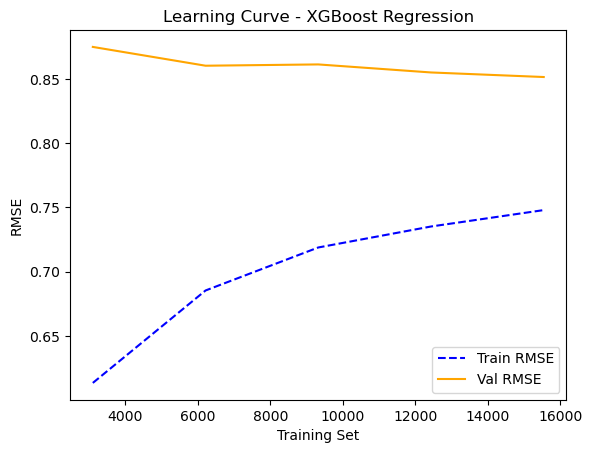

In [56]:
sizes, train_scores, val_scores = learning_curve(
    XGBRegressor(objective='reg:squarederror',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7),
    X_train, 
    y_train_lin,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0],
)
#===========================================================================================
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_rmse, '--', color='blue', label='Train RMSE')
plt.plot(sizes, val_rmse, color='orange', label='Val RMSE')
plt.xlabel('Training Set')
plt.ylabel('RMSE')
plt.legend()
plt.title('Learning Curve - XGBoost Regression')
plt.show()

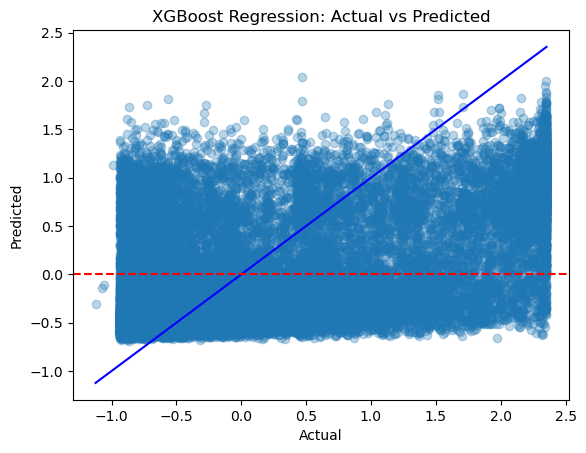

In [57]:
plt.scatter(y_val_lin, pred_val_xgbr, alpha=0.3)
p1 = max(max(pred_val_xgbr), max(y_val_lin))
p2 = min(min(pred_val_xgbr), min(y_val_lin))
plt.plot([p1,p2],[p1,p2],'b-')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost Regression: Actual vs Predicted')
plt.show()

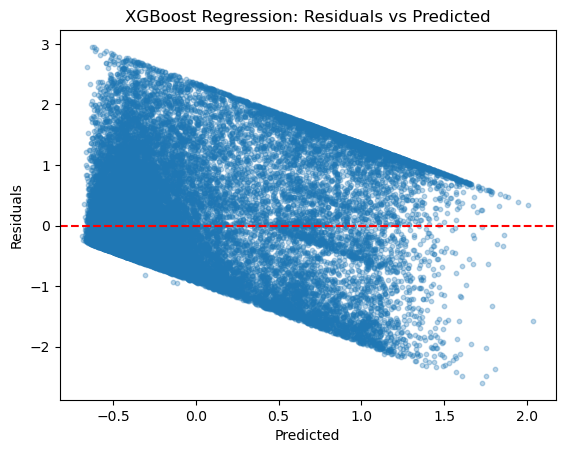

In [58]:
resid = y_val_lin - pred_val_xgbr
plt.scatter(pred_val_xgbr, resid, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('XGBoost Regression: Residuals vs Predicted')
plt.show()

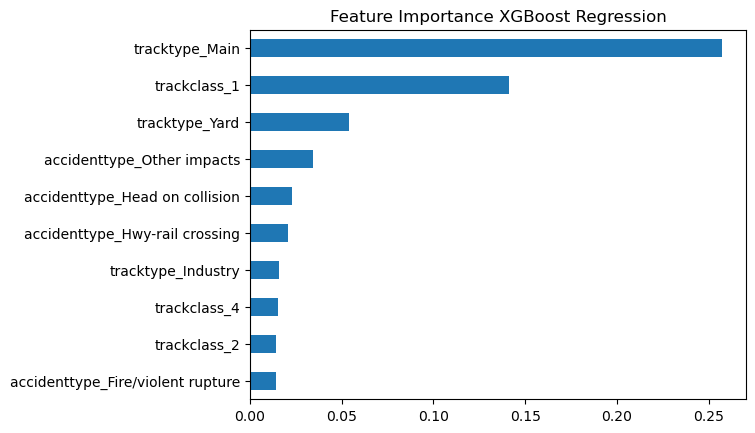

In [59]:
importance = pd.Series(xgbr.feature_importances_,index=X_train.columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance XGBoost Regression')
plt.show()

### Baseline Model - KNN

In [60]:
knn_by = KNeighborsClassifier(n_neighbors=5)
knn_by.fit(X_train, y_train_knn)
pred_val_knn_by=knn_by.predict(X_val)
results_by = classification_report(y_val_knn, pred_val_knn_by)
#===========================================================================================
print("Classification Report - With Year")
print(results_by)

Classification Report - With Year
               precision    recall  f1-score   support

High Severity       0.64      0.54      0.59     16841
 Low Severity       0.57      0.67      0.61     15282

     accuracy                           0.60     32123
    macro avg       0.61      0.60      0.60     32123
 weighted avg       0.61      0.60      0.60     32123



#### KNN Tuning Best K

In [61]:
# param_grid = {
#     'select__k' : [20,50,100],
#     'knn__n_neighbors': [20,50,100],
#     'knn__weights': ['uniform','distance'],
#     'knn__p': [1,2]
# }
# #====================================================
# grid_knn = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
# grid_knn.fit(X_train, y_train_knn)
# print(f"Best params: {grid_knn.best_params_}")
# print(f"Best CV F1 (Macro): {grid_knn.best_score_:.3f}")
# #====================================================
# Best params: {'knn__n_neighbors': 100, 'knn__p': 1, 'knn__weights': 'distance', 'select__k': 100}
# Best CV F1 (Macro): 0.663

In [62]:
knn_gs = Pipeline([('select',SelectKBest(score_func=f_classif, k=100)),('knn',KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'distance'))])
knn_gs.fit(X_train, y_train_knn)
pred_val_knn_gs=knn_gs.predict(X_val)
results_gs = classification_report(y_val_knn, pred_val_knn_gs)
#===========================================================================================
print("Classification Report")
print(results_gs)

Classification Report
               precision    recall  f1-score   support

High Severity       0.73      0.48      0.58     16841
 Low Severity       0.59      0.80      0.68     15282

     accuracy                           0.64     32123
    macro avg       0.66      0.64      0.63     32123
 weighted avg       0.66      0.64      0.63     32123



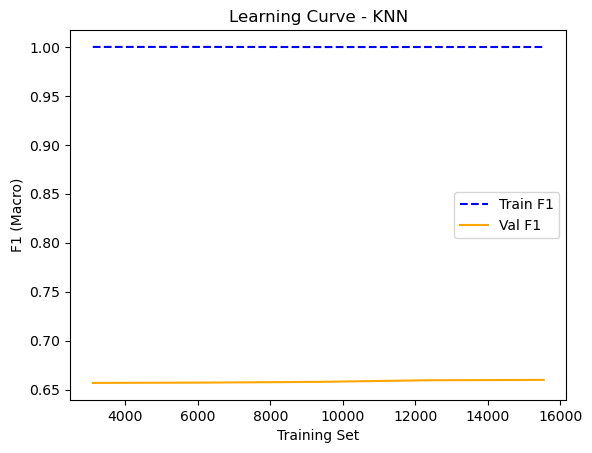

In [63]:
sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'distance'),
    X_train, y_train_knn, cv=tscv, scoring='f1_macro',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0])
#===========================================================================================
train_f1 = train_scores.mean(axis=1)
val_f1 = val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_f1, '--', color='blue', label='Train F1')
plt.plot(sizes, val_f1, color='orange', label='Val F1')
plt.xlabel('Training Set')
plt.ylabel('F1 (Macro)')
plt.legend()
plt.title('Learning Curve - KNN')
plt.show()

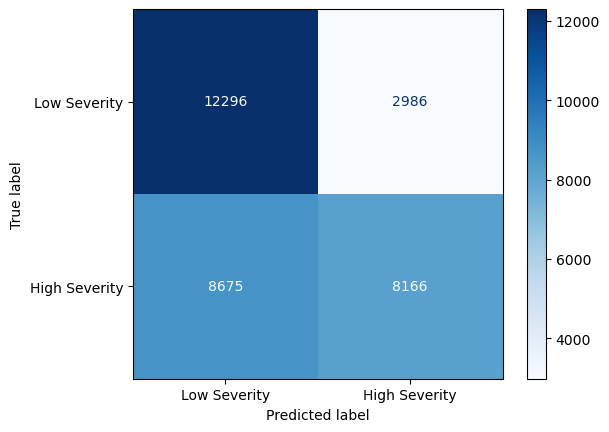

In [64]:
labels=['Low Severity', 'High Severity']
cm = confusion_matrix(y_val_knn, pred_val_knn_gs, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

#### KNN Tuning without Best K

In [65]:
# param_grid = {
#     'n_neighbors': [20,50,100],
#     'weights': ['uniform','distance'],
#     'p': [1,2]
# }

# knn = KNeighborsClassifier()
# grid_knn = GridSearchCV(knn, param_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
# grid_knn.fit(X_train, y_train_knn)
# print(f"Best params: {grid_knn.best_params_}")
# print(f"Best CV F1 (Weighted): {grid_knn.best_score_:.3f}")
# #==========================================================
# Best params: {'n_neighbors': 100, 'p': 1, 'weights': 'uniform'}
# Best CV F1 (Weighted): 0.662

In [66]:
knn_gs2 = KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'uniform')
knn_gs2.fit(X_train, y_train_knn)
pred_val_knn_gs2=knn_gs2.predict(X_val)
results_gs2 = classification_report(y_val_knn, pred_val_knn_gs2)
#===========================================================================================
print("Classification Report")
print(results_gs2)

Classification Report
               precision    recall  f1-score   support

High Severity       0.73      0.49      0.59     16841
 Low Severity       0.59      0.80      0.68     15282

     accuracy                           0.64     32123
    macro avg       0.66      0.65      0.63     32123
 weighted avg       0.66      0.64      0.63     32123



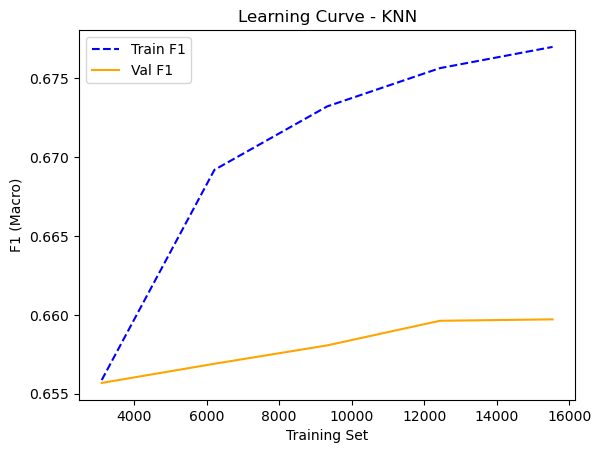

In [67]:
sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(n_neighbors = 100, p = 1, weights = 'uniform'),
    X_train, y_train_knn, cv=tscv, scoring='f1_macro',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0])
#===========================================================================================
train_f12 = train_scores.mean(axis=1)
val_f12 = val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_f12, '--', color='blue', label='Train F1')
plt.plot(sizes, val_f12, color='orange', label='Val F1')
plt.xlabel('Training Set')
plt.ylabel('F1 (Macro)')
plt.legend()
plt.title('Learning Curve - KNN')
plt.show()

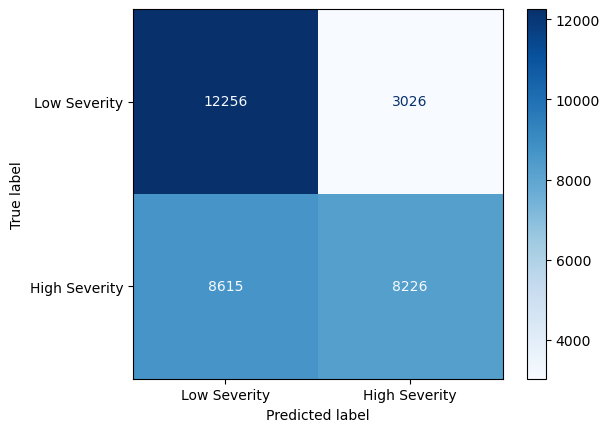

In [68]:
labels=['Low Severity', 'High Severity']
cm = confusion_matrix(y_val_knn, pred_val_knn_gs2, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Non-Linear Classification Models

In [69]:
label = LabelEncoder()
y_train_label = label.fit_transform(y_train_knn)
print(label.classes_)

# param_grid = {
#     'n_estimators': [700,800,900],
#     'max_depth': [7,11,13],
#     'learning_rate': [0.01,0.05],
#     'subsample': [0.7,0.9],
#     'colsample_bytree': [0.7,0.9]
# }

# xgbc = XGBClassifier(objective='binary:logistic',random_state=42)
# grid_xgbc = GridSearchCV(xgbc, param_grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
# grid_xgbc.fit(X_train, y_train_label)
# print(f"Best params: {grid_xgbc.best_params_}")
# print(f"Best CV F1 (Macro): {grid_xgbc.best_score_:.3f}")
# #==========================================================================================================
# Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.7}
# Best CV F1 (Macro): 0.675

['High Severity' 'Low Severity']


#### Non-Linear Classification Evaluated

In [70]:
xgbc = XGBClassifier(objective='binary:logistic',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7)
xgbc.fit(X_train, y_train_label)
pred_val_xgbc=xgbc.predict(X_val)
#===========================================================================================
y_val_label = label.transform(y_val_knn)
#===========================================================================================
results_xgbc = classification_report(y_val_label, pred_val_xgbc)
print("Classification Report")
print(results_xgbc)

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.57      0.63     16841
           1       0.61      0.75      0.68     15282

    accuracy                           0.66     32123
   macro avg       0.66      0.66      0.65     32123
weighted avg       0.67      0.66      0.65     32123



In [71]:
score_xgbc = cross_val_score(xgbc, X_train, y_train_label, cv=tscv, scoring='f1_macro')
print("XGBoost Classification")
print(f"Mean F1 (Marco): {score_xgbc.mean():.3f}")
print(f"Std F1 (Marco): {score_xgbc.std():.3f}")
print(f"Per-fold: {score_xgbc}")

XGBoost Classification
Mean F1 (Marco): 0.676
Std F1 (Marco): 0.005
Per-fold: [0.6802442  0.68034973 0.67869593 0.67219873 0.66878332]


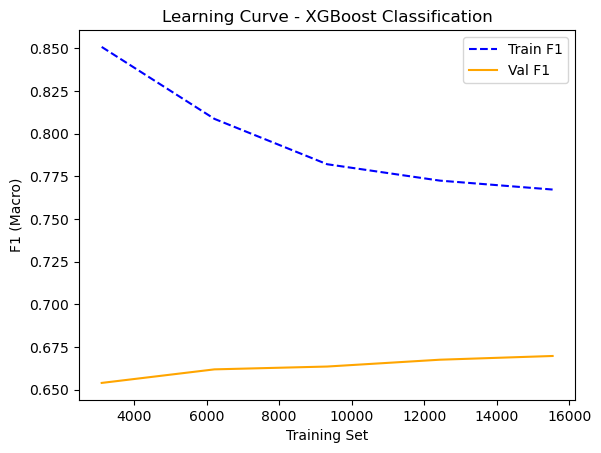

In [72]:
sizes, train_scores, val_scores = learning_curve(
        XGBClassifier(objective='binary:logistic',
                    random_state=42,
                    colsample_bytree=0.7,
                    learning_rate=0.01,
                    max_depth=7, 
                    n_estimators=700,
                    subsample=0.7),
    X_train, y_train_label, cv=tscv, scoring='f1_macro',
    train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0])
#===========================================================================================
train_f1 = train_scores.mean(axis=1)
val_f1 = val_scores.mean(axis=1)
#===========================================================================================
plt.plot(sizes, train_f1, '--', color='blue', label='Train F1')
plt.plot(sizes, val_f1, color='orange', label='Val F1')
plt.xlabel('Training Set')
plt.ylabel('F1 (Macro)')
plt.legend()
plt.title('Learning Curve - XGBoost Classification')
plt.show()

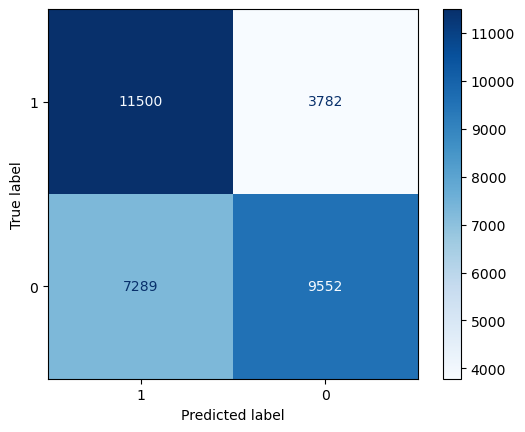

In [73]:
labels=[1,0]
cm = confusion_matrix(y_val_label, pred_val_xgbc, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

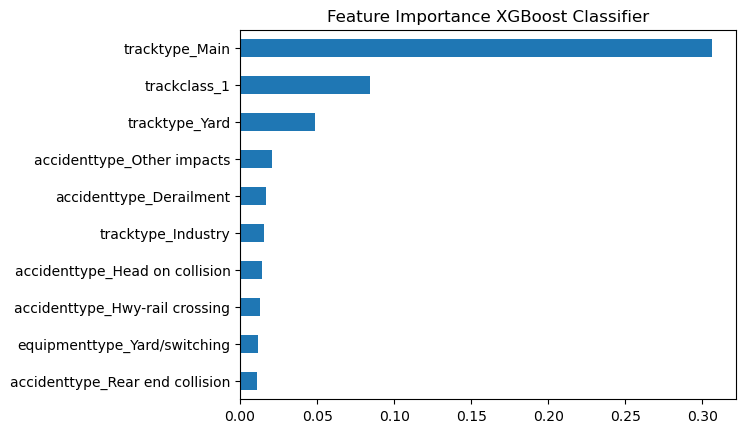

In [74]:
importance = pd.Series(xgbc.feature_importances_,index=X_train.columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance XGBoost Classifier')
plt.show()

### Result Tables

In [75]:
regression_results = pd.DataFrame({'Model':['Linear Regression','+ year_weights', '+ SelectKBest (116 features)','XGBoost Regressor (Tuned)'],
                                   'Val RMSE':[0.889, 0.886, 0.886, 0.889],
                                   'R-squared':[0.252, 0.257, 0.257, 0.293]})
display(regression_results)

,Model,Val RMSE,R-squared
0,Linear Regression,0.889,0.252
1,+ year_weights,0.886,0.257
2,+ SelectKBest (116 features),0.886,0.257
3,XGBoost Regressor (Tuned),0.889,0.293


In [76]:
class_results = pd.DataFrame({'Model':['Base KNN (n_neighbors=5)','Tuned KNN', 'XGBoost Classifier (Tuned)'],
                              'Accuracy':[0.60, 0.64, 0.66],
                              'High Severity Recall':[0.54, 0.49, 0.57],
                              'High Severity F1-score':[0.59, 0.59, 0.63],
                              'Low Severity F1-score':[0.62, 0.68, 0.68]})
display(class_results)

,Model,Accuracy,High Severity Recall,High Severity F1-score,Low Severity F1-score
0,Base KNN (n_neighbors=5),0.60,0.54,0.59,0.62
1,Tuned KNN,0.64,0.49,0.59,0.68
2,XGBoost Classifier (Tuned),0.66,0.57,0.63,0.68


### Naive Model

In [77]:
mean = DummyRegressor(strategy="mean")
mean.fit(X_train, y_train_lin)
y_pred_mean = mean.predict(X_val)
dr_rmse_mean = root_mean_squared_error(y_val_lin, y_pred_mean)
print(f"Mean (Val) RMSE: {dr_rmse_mean}")

Mean (Val) RMSE: 1.0294066647189366


In [78]:
stratified = DummyClassifier(strategy="stratified", random_state=42)
stratified.fit(X_train, y_train_knn)
y_pred_stratified = stratified.predict(X_val)
f1_stratified = f1_score(y_val_knn, y_pred_stratified, average='macro')
print(f"Stratified (Val) F1 Score (Macro): {f1_stratified:.3f}")

Stratified (Val) F1 Score (Macro): 0.494


### Regression T-Test and Confidence Intervals

In [79]:
model_xgb_reg = XGBRegressor(objective='reg:squarederror',random_state=42,colsample_bytree=0.7,learning_rate=0.01,max_depth=7, n_estimators=700,subsample=0.7)
model_dummy_reg = DummyRegressor(strategy="mean")
#===========================================================================================
scores_xgb_rmse = cross_val_score(model_xgb_reg, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
scores_dummy_rmse = cross_val_score(model_dummy_reg, X_train, y_train_lin, cv=tscv, scoring='neg_root_mean_squared_error')
#===========================================================================================
scores_xgb_rmse = -scores_xgb_rmse
scores_dummy_rmse = -scores_dummy_rmse
#===========================================================================================
scores_xgb_r2 = cross_val_score(model_xgb_reg, X_train, y_train_lin, cv=tscv, scoring='r2')
scores_dummy_r2 = cross_val_score(model_dummy_reg, X_train, y_train_lin, cv=tscv, scoring='r2')
#===========================================================================================
print("RMSE Scores")
print(f"XGBoost Regression - Mean RMSE: {scores_xgb_rmse.mean():.3f} (+/- {scores_xgb_rmse.std():.3f})")
print(f"Dummy Baseline - Mean RMSE: {scores_dummy_rmse.mean():.3f} (+/- {scores_dummy_rmse.std():.3f})")
print(f"\nR-squared Scores")
print(f"XGBoost Regression - Mean R2: {scores_xgb_r2.mean():.3f} (+/- {scores_xgb_r2.std():.3f})")
print(f"Dummy Baseline - Mean R2: {scores_dummy_r2.mean():.3f} (+/- {scores_dummy_r2.std():.3f})")

RMSE Scores
XGBoost Regression - Mean RMSE: 0.840 (+/- 0.017)
Dummy Baseline - Mean RMSE: 0.997 (+/- 0.020)

R-squared Scores
XGBoost Regression - Mean R2: 0.288 (+/- 0.021)
Dummy Baseline - Mean R2: -0.002 (+/- 0.001)


In [80]:
t_stat_r2, p_value_r2 = ttest_rel(scores_xgb_r2, scores_dummy_r2)
print("Paired t-test (R-squared)")
print(f"t-statistic: {t_stat_r2:.3f}")
print(f"p-value: {p_value_r2:.7f}")
print(f"Mean R2 difference: {(scores_xgb_r2 - scores_dummy_r2).mean():.3f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_r2 < 0.05:
    print("REJECT H0 - Significant difference in R-squared.")
else:
    print("FAIL TO REJECT H0 - No significant difference.")
#===========================================================================================
#===========================================================================================
t_stat_rmse, p_value_rmse = ttest_rel(scores_xgb_rmse, scores_dummy_rmse)
print("Paired t-test (RMSE)")
print(f"t-statistic: {t_stat_rmse:.3f}")
print(f"p-value: {p_value_rmse:.7f}")
print(f"Mean RMSE difference: {(scores_xgb_rmse - scores_dummy_rmse).mean():.3f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_rmse < 0.05:
    print("REJECT H0 - Significant difference in RMSE.")
else:
    print("FAIL TO REJECT H0 - No significant difference.")

Paired t-test (R-squared)
t-statistic: 26.879
p-value: 0.0000114
Mean R2 difference: 0.290

Conclusion at alpha=0.05: REJECT H0 - Significant difference in R-squared.
Paired t-test (RMSE)
t-statistic: -22.238
p-value: 0.0000242
Mean RMSE difference: -0.157

Conclusion at alpha=0.05: REJECT H0 - Significant difference in RMSE.


In [81]:
bootstrap = 10000
np.random.seed(42)
#===========================================================================================
diff_r2 = scores_xgb_r2 - scores_dummy_r2
bootstrap_r2 = []
for _ in range(bootstrap):
    sample = np.random.choice(diff_r2, size=len(diff_r2), replace=True)
    bootstrap_r2.append(sample.mean())
bootstrap_r2 = np.array(bootstrap_r2)
#===========================================================================================
print("Bootstrap 95% CI for R-squared Difference")
ci_r2_lower, ci_r2_upper = np.percentile(bootstrap_r2, [2.5, 97.5])
print(f"Mean R2 Diff: {diff_r2.mean():.3f}")
print(f"95% CI: {ci_r2_lower:.3f}, {ci_r2_upper:.3f}")
print(f"Contain 0: {'Yes' if ci_r2_lower <= 0 <= ci_r2_upper else 'No'}")
print("\n")
#===========================================================================================
#===========================================================================================
diff_rmse = scores_xgb_rmse - scores_dummy_rmse
bootstrap_rmse = []
for _ in range(bootstrap):
    sample = np.random.choice(diff_rmse, size=len(diff_rmse), replace=True)
    bootstrap_rmse.append(sample.mean())
bootstrap_rmse = np.array(bootstrap_rmse)
#===========================================================================================
print("Bootstrap 95% CI for RMSE Difference")
ci_rmse_lower, ci_rmse_upper = np.percentile(bootstrap_rmse, [2.5, 97.5])
print(f"Mean RMSE Diff: {diff_rmse.mean():.3f}")
print(f"95% CI: {ci_rmse_lower:.3f}, {ci_rmse_upper:.3f}")
print(f"Contain 0: {'Yes' if ci_rmse_lower <= 0 <= ci_rmse_upper else 'No'}")

Bootstrap 95% CI for R-squared Difference
Mean R2 Diff: 0.290
95% CI: 0.271, 0.308
Contain 0: No


Bootstrap 95% CI for RMSE Difference
Mean RMSE Diff: -0.157
95% CI: -0.169, -0.144
Contain 0: No


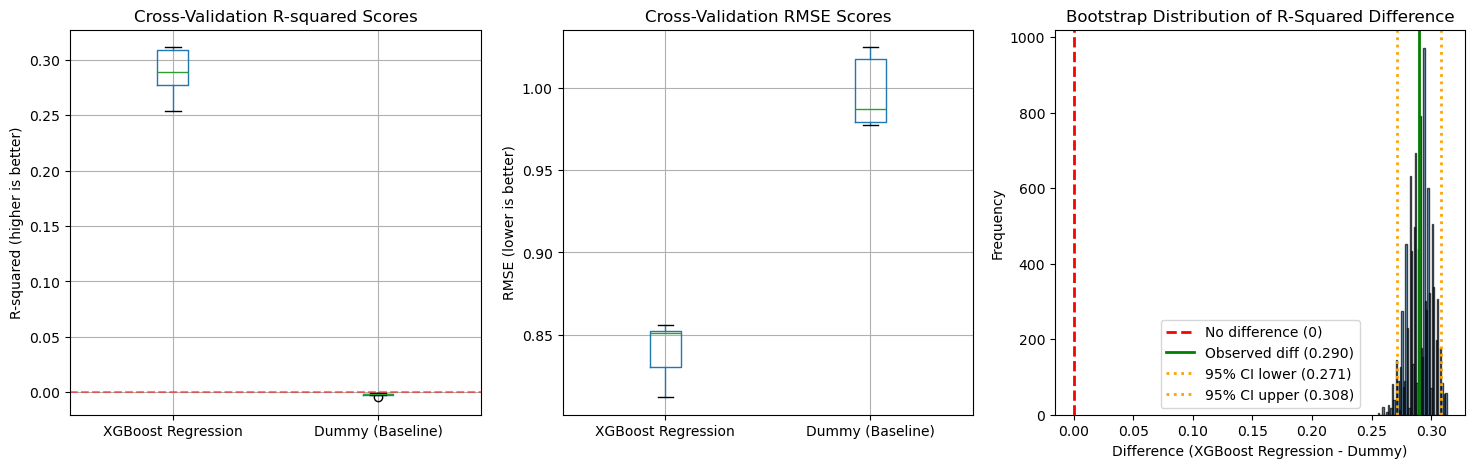

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#===========================================================================================
r2_df = pd.DataFrame({
    'XGBoost Regression': scores_xgb_r2,
    'Dummy (Baseline)': scores_dummy_r2
})
r2_df.boxplot(ax=axes[0])
axes[0].set_title('Cross-Validation R-squared Scores')
axes[0].set_ylabel('R-squared (higher is better)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
#===========================================================================================
#===========================================================================================
rmse_df = pd.DataFrame({
    'XGBoost Regression': scores_xgb_rmse,
    'Dummy (Baseline)': scores_dummy_rmse
})
rmse_df.boxplot(ax=axes[1])
axes[1].set_title('Cross-Validation RMSE Scores')
axes[1].set_ylabel('RMSE (lower is better)')
#===========================================================================================
axes[2].hist(bootstrap_r2, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference (0)')
axes[2].axvline(x=diff_r2.mean(), color='green', linestyle='-', linewidth=2, label=f'Observed diff ({diff_r2.mean():.3f})')
axes[2].axvline(x=ci_r2_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI lower ({ci_r2_lower:.3f})')
axes[2].axvline(x=ci_r2_upper, color='orange', linestyle=':', linewidth=2, label=f'95% CI upper ({ci_r2_upper:.3f})')
axes[2].set_title('Bootstrap Distribution of R-Squared Difference')
axes[2].set_xlabel('Difference (XGBoost Regression - Dummy)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
#===========================================================================================
plt.tight_layout
plt.show()

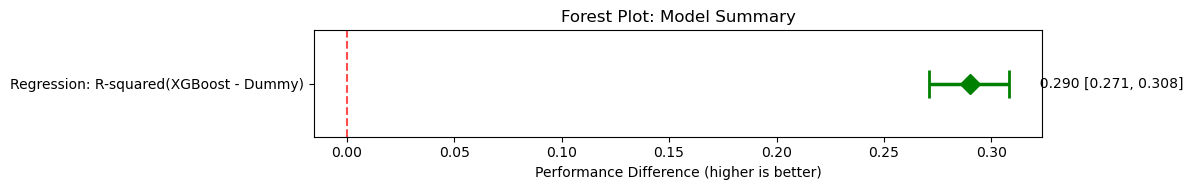

In [83]:
fig, ax = plt.subplots(figsize=(12,2))
comparisons =[{'label':'Regression: R-squared(XGBoost - Dummy)',
              'mean':diff_r2.mean(),
              'lower':ci_r2_lower,
              'upper':ci_r2_upper}]
#===========================================================================================
for i, comp in enumerate(comparisons):
    color = 'green' if comp['lower'] > 0 else ('red' if comp['upper'] < 0 else 'gray')
    ax.errorbar(comp['mean'], i,
                xerr=[[comp['mean'] - comp['lower']], [comp['upper'] - comp['mean']]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    ax.text(comp['upper'] + 0.01, i,
            f"  {comp['mean']:.3f} [{comp['lower']:.3f}, {comp['upper']:.3f}]",
            va='center', fontsize=10)
#===========================================================================================
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(range(len(comparisons)))
ax.set_yticklabels([c['label'] for c in comparisons])
ax.set_xlabel('Performance Difference (higher is better)')
ax.set_title('Forest Plot: Model Summary')
plt.tight_layout()
plt.show()

### Classification T-Test and Confidence Intervals

In [84]:
model_xgb_cl = XGBClassifier(objective='binary:logistic',random_state=42,colsample_bytree=0.7,learning_rate=0.01,max_depth=7, n_estimators=700,subsample=0.7)
model_dummy_cl = DummyClassifier(strategy="stratified", random_state=42)
#===========================================================================================
scores_xgb_f1m = cross_val_score(model_xgb_cl, X_train, y_train_label, cv=tscv, scoring='f1_macro')
scores_dummy_f1m = cross_val_score(model_dummy_cl, X_train, y_train_label, cv=tscv, scoring='f1_macro')
#===========================================================================================
print("F1 Macro Scores")
print(f"XGBoost Classification - Mean F1 Macro: {scores_xgb_f1m.mean():.3f} (+/- {scores_xgb_f1m.std():.3f})")
print(f"Dummy Baseline - Mean F1 Macro: {scores_dummy_f1m.mean():.3f} (+/- {scores_dummy_f1m.std():.3f})")
print(f"Number of paired scores: {len(scores_xgb_f1m)}")
print(f"Observed Mean Diff: {scores_xgb_f1m.mean() - scores_dummy_f1m.mean():.3f}")

F1 Macro Scores
XGBoost Classification - Mean F1 Macro: 0.676 (+/- 0.005)
Dummy Baseline - Mean F1 Macro: 0.503 (+/- 0.002)
Number of paired scores: 5
Observed Mean Diff: 0.173


In [85]:
t_stat_f1m, p_value_f1m = ttest_rel(scores_xgb_f1m, scores_dummy_f1m)
print("Paired t-test (F1 Macro)")
print(f"t-statistic: {t_stat_f1m:.3f}")
print(f"p-value: {p_value_f1m:.7f}")
print(f"Mean F1 Macro difference: {(scores_xgb_f1m - scores_dummy_f1m).mean():.3f}")
print(f"\nConclusion at alpha=0.05: ", end="")
if p_value_f1m < 0.05:
    print("REJECT H0 - Significant difference in F1 Macro.")
else:
    print("FAIL TO REJECT H0 - No significant difference.")

Paired t-test (F1 Macro)
t-statistic: 57.203
p-value: 0.0000006
Mean F1 Macro difference: 0.173

Conclusion at alpha=0.05: REJECT H0 - Significant difference in F1 Macro.


In [86]:
bootstrap = 10000
np.random.seed(42)
#======================================================================================
diff_f1m = scores_xgb_f1m - scores_dummy_f1m
observed_diff_f1m = diff_f1m.mean()
#======================================================================================
bootstrap_f1m = []
for _ in range(bootstrap):
    sample = np.random.choice(diff_f1m, size=len(diff_f1m), replace=True)
    bootstrap_f1m.append(sample.mean())
bootstrap_f1m = np.array(bootstrap_f1m)
#======================================================================================
print("Bootstrap 95% CI for F1 Macro Difference")
ci_f1m_lower, ci_f1m_upper = np.percentile(bootstrap_f1m, [2.5, 97.5])
print(f"Mean F1 Macro Diff: {observed_diff_f1m.mean():.3f}")
print(f"95% CI: {ci_f1m_lower:.3f}, {ci_f1m_upper:.3f}")
print(f"Contain 0: {'Yes' if ci_f1m_lower <= 0 <= ci_f1m_upper else 'No'}")

Bootstrap 95% CI for F1 Macro Difference
Mean F1 Macro Diff: 0.173
95% CI: 0.168, 0.179
Contain 0: No


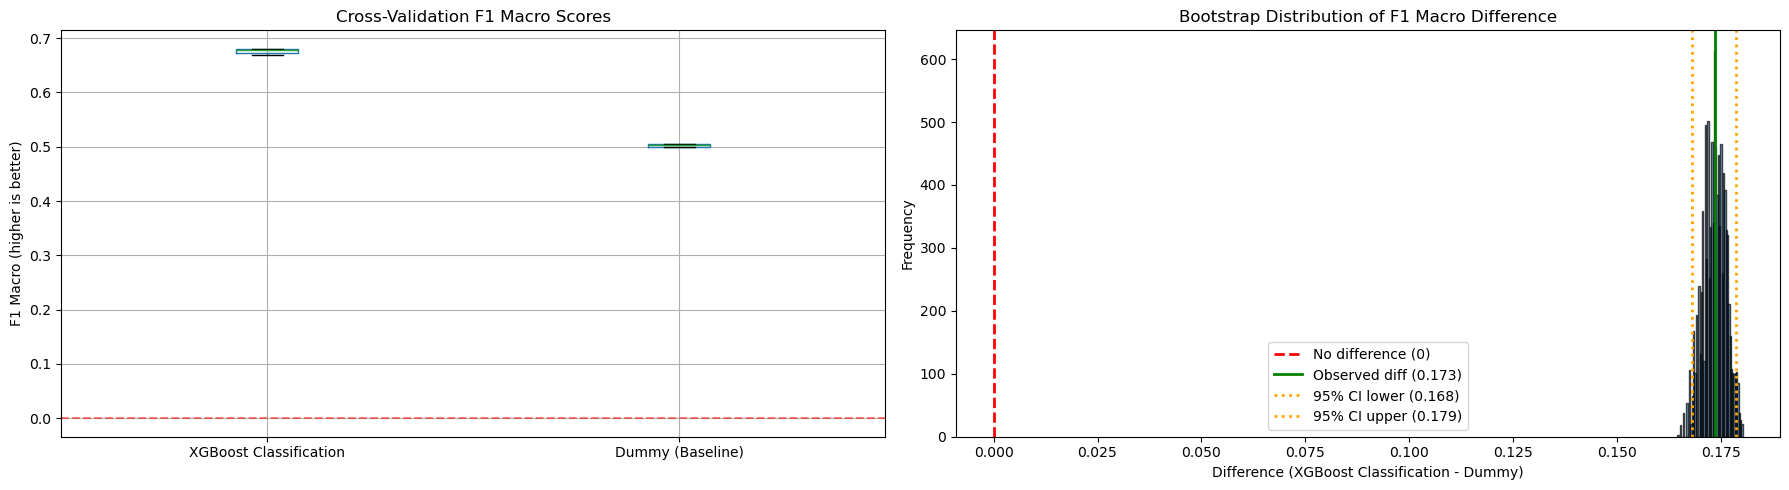

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
#=======================================================================================
f1m_df = pd.DataFrame({
    'XGBoost Classification': scores_xgb_f1m,
    'Dummy (Baseline)': scores_dummy_f1m})
f1m_df.boxplot(ax=axes[0])
axes[0].set_title('Cross-Validation F1 Macro Scores')
axes[0].set_ylabel('F1 Macro (higher is better)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
#=======================================================================================
axes[1].hist(bootstrap_f1m, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference (0)')
axes[1].axvline(x=observed_diff_f1m, color='green', linestyle='-', linewidth=2, label=f'Observed diff ({observed_diff_f1m:.3f})')
axes[1].axvline(x=ci_f1m_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI lower ({ci_f1m_lower:.3f})')
axes[1].axvline(x=ci_f1m_upper, color='orange', linestyle=':', linewidth=2, label=f'95% CI upper ({ci_f1m_upper:.3f})')
axes[1].set_title('Bootstrap Distribution of F1 Macro Difference')
axes[1].set_xlabel('Difference (XGBoost Classification - Dummy)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
#=======================================================================================
plt.tight_layout()
plt.show()

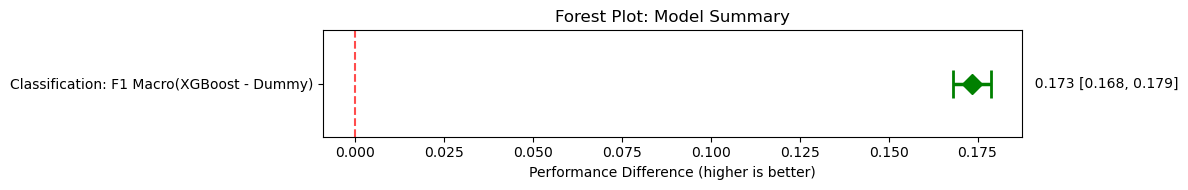

In [88]:
fig, axes = plt.subplots(figsize=(12,2))
comparisons =[{'label':'Classification: F1 Macro(XGBoost - Dummy)',
              'mean':diff_f1m.mean(),
              'lower':ci_f1m_lower,
              'upper':ci_f1m_upper}]
#===========================================================================================
for i, comp in enumerate(comparisons):
    color = 'green' if comp['lower'] > 0 else ('red' if comp['upper'] < 0 else 'gray')
    axes.errorbar(comp['mean'], i,
                xerr=[[comp['mean'] - comp['lower']], [comp['upper'] - comp['mean']]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    axes.text(comp['upper'] + 0.01, i,
            f"  {comp['mean']:.3f} [{comp['lower']:.3f}, {comp['upper']:.3f}]",
            va='center', fontsize=10)
#===========================================================================================
axes.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes.set_yticks(range(len(comparisons)))
axes.set_yticklabels([c['label'] for c in comparisons])
axes.set_xlabel('Performance Difference (higher is better)')
axes.set_title('Forest Plot: Model Summary')
plt.tight_layout()
plt.show()

### Final Model Results

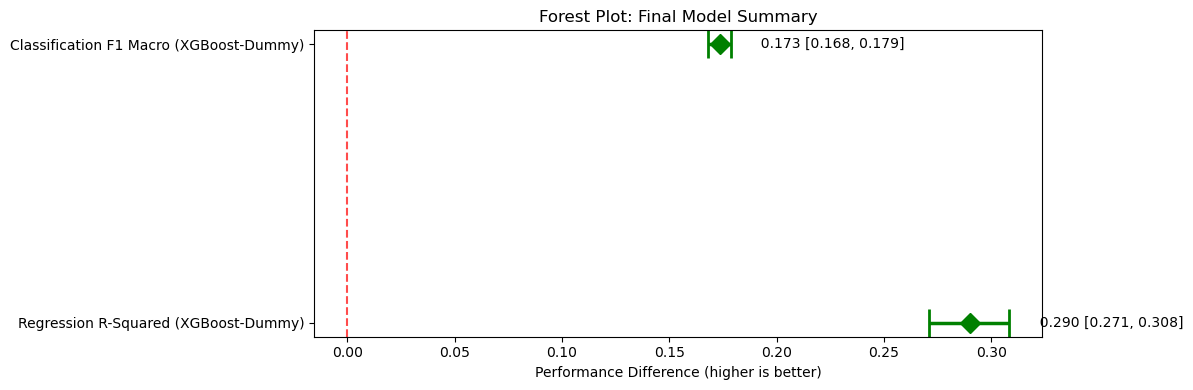

In [89]:
fig, axes = plt.subplots(figsize=(12,4))
comparisons = [
    {"label": "Regression R-Squared (XGBoost-Dummy)",
     "mean": diff_r2.mean(),
     "lower": ci_r2_lower,
     "upper": ci_r2_upper},
    {"label": "Classification F1 Macro (XGBoost-Dummy)",
     "mean": diff_f1m.mean(),
     "lower": ci_f1m_lower,
     "upper": ci_f1m_upper}]
#===========================================================================================
for i, comp in enumerate(comparisons):
    color = 'green' if comp['lower'] > 0 else ('red' if comp['upper'] < 0 else 'gray')
    axes.errorbar(comp['mean'], i,
                xerr=[[comp['mean'] - comp['lower']], [comp['upper'] - comp['mean']]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    axes.text(comp['upper'] + 0.01, i,
            f"  {comp['mean']:.3f} [{comp['lower']:.3f}, {comp['upper']:.3f}]",
            va='center', fontsize=10)
#===========================================================================================
axes.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes.set_yticks(range(len(comparisons)))
axes.set_yticklabels([c['label'] for c in comparisons])
axes.set_xlabel('Performance Difference (higher is better)')
axes.set_title('Forest Plot: Final Model Summary')
plt.tight_layout()
plt.show()

In [90]:
results_summary = pd.DataFrame({
    'Comparison': ['Classification (F1 Macro)', 'Regression (R-squared)', 'Regression (RMSE)'],
    'Model Mean': [
        f"{scores_xgb_f1m.mean():.3f}",
        f"{scores_xgb_r2.mean():.3f}",
        f"{scores_xgb_rmse.mean():.3f}"],
    'Baseline Mean': [
        f"{scores_dummy_f1m.mean():.3f}",
        f"{scores_dummy_r2.mean():.3f}",
        f"{scores_dummy_rmse.mean():.3f}"],
    'Mean Diff': [
        f"{diff_f1m.mean():.3f}",
        f"{diff_r2.mean():.3f}",
        f"{diff_rmse.mean():.3f}"],
    '95% CI': [
        f"[{ci_f1m_lower:.3f}, {ci_f1m_upper:.3f}]",
        f"[{ci_r2_lower:.3f}, {ci_r2_upper:.3f}]",
        f"[{ci_rmse_lower:.3f}, {ci_rmse_upper:.3f}]"],
    'p-value (t-test)': [
        f"{p_value_f1m:.6f}",
        f"{p_value_r2:.6f}",
        f"{p_value_rmse:.6f}"],
    'Significant?': [
        'Yes' if p_value_f1m < 0.05 else 'No',
        'Yes' if p_value_r2 < 0.05 else 'No',
        'Yes' if p_value_rmse < 0.05 else 'No']})
#===========================================================================================
print("Summary of All Model Comparisons")
display(results_summary)

Summary of All Model Comparisons


,Comparison,Model Mean,Baseline Mean,Mean Diff,95% CI,p-value (t-test),Significant?
0,Classification (F1 Macro),0.676,0.503,0.173,"[0.168, 0.179]",0.000001,Yes
1,Regression (R-squared),0.288,-0.002,0.290,"[0.271, 0.308]",0.000011,Yes
2,Regression (RMSE),0.840,0.997,-0.157,"[-0.169, -0.144]",0.000024,Yes


### Test Set Final Results

#### Regression Test

In [91]:
pred_test_xgbr = xgbr.predict(X_test)
rmse_test_xgbr = np.sqrt(mean_squared_error(y_test_lin, pred_test_xgbr))
r2_test_xgbr = r2_score(y_val_lin, pred_val_xgbr)
#===========================================================================================
print(f" Test RMSE: {rmse_test_xgbr:.3f}")
print(f" R2-Score: {r2_test_xgbr:.3f}")

 Test RMSE: 0.933
 R2-Score: 0.294


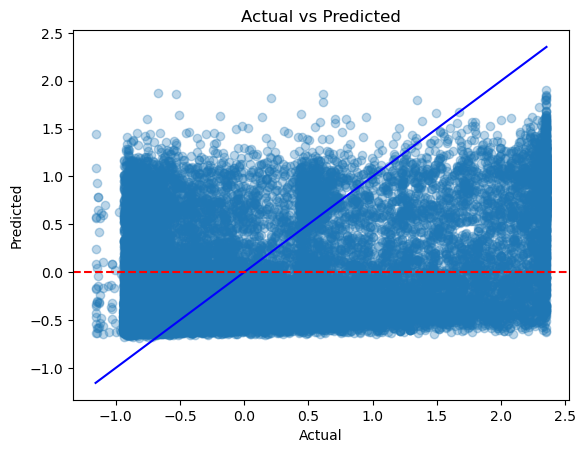

In [92]:
plt.scatter(y_test_lin, pred_test_xgbr, alpha=0.3)
p1 = max(max(pred_test_xgbr), max(y_test_lin))
p2 = min(min(pred_test_xgbr), min(y_test_lin))
plt.plot([p1,p2],[p1,p2],'b-')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

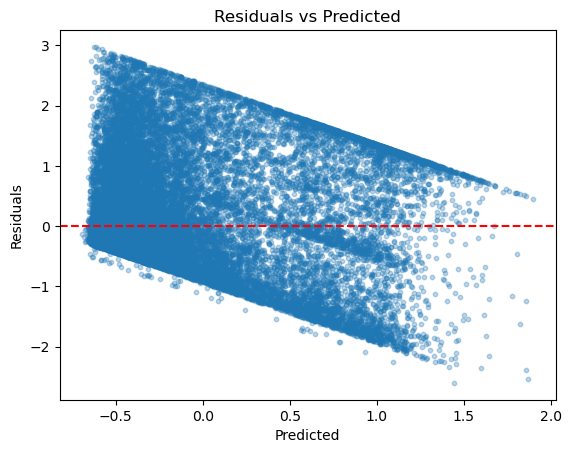

In [93]:
resid = y_test_lin - pred_test_xgbr
plt.scatter(pred_test_xgbr, resid, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

#### Classification Test

In [94]:
y_test_label = label.transform(y_test_knn)
pred_test_xgbc = xgbc.predict(X_test)
#===========================================================================================
results_xgbc = classification_report(y_test_label, pred_test_xgbc)
print("Classification Report")
print(results_xgbc)

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.50      0.58     15449
           1       0.56      0.74      0.63     13200

    accuracy                           0.61     28649
   macro avg       0.62      0.62      0.61     28649
weighted avg       0.63      0.61      0.60     28649



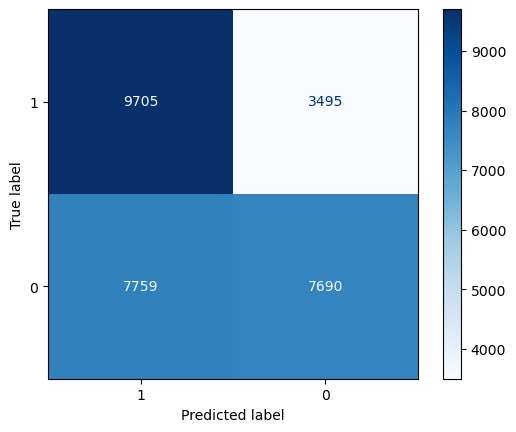

In [95]:
labels=[1,0]
cm = confusion_matrix(y_test_label, pred_test_xgbc, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()